# Notebook support pour un projet ML supervisé (classification)
## Notebook 4 - Tests d'autres modèles

Commençons par charger les données de sortie de la phase de feature engineering.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import sys
from pathlib import Path


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
 )

sys.path.append(str(Path.cwd().parent))

import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

df_MODEL = pd.read_csv("../data/processed/df_MODEL.csv")


## Séparation du jeu de données en : train/test (80 %) pour la CV + test final (20 %)

**N.B. :** Ici, nous prenons notre travail de feature engineering en compte.


In [2]:
# 1. Split final sanctuarise
target = "a_quitte_l_entreprise"

X = df_MODEL.drop(columns=[target, "id_employee"])
y = df_MODEL[target]

X_model, X_final_test, y_model, y_final_test = train_test_split(X,y,test_size=0.20,random_state=4,stratify=y,)

print("X_model      :", X_model.shape)
print("X_final_test :", X_final_test.shape)
print("y_model      :", y_model.shape)
print("y_final_test :", y_final_test.shape)

X_model      : (1176, 58)
X_final_test : (294, 58)
y_model      : (1176,)
y_final_test : (294,)


## Tests d'autres modèles que la baseline

Selon les recommandations de choix de la documentation scikit-learn, nous décidons de tester les modèles suivants :  
- Linear SVC ;  
- KNeighbors Classifier ;  
- SVC ;  
- modèles d'ensemble (`Random Forest`, `Gradient Boosting` et `AdaBoost`) ;
- ainsi qu'une nouvelle exécution de la régression logistique.



Logistic Regression
Train | Accuracy: 0.7993 +/- 0.0064 | Precision: 0.4345 +/- 0.0102 | Recall: 0.8013 +/- 0.0174 | F1: 0.5634 +/- 0.0114 | ROC AUC: 0.8837 +/- 0.0067 | PR-AUC: 0.6853 +/- 0.0268
Test  | Accuracy: 0.7636 +/- 0.0178 | Precision: 0.3768 +/- 0.0319 | Recall: 0.7158 +/- 0.0947 | F1: 0.4931 +/- 0.0486 | ROC AUC: 0.8146 +/- 0.0417 | PR-AUC: 0.5933 +/- 0.0670
Temps | Total CV: 0.4999s | Moyenne par fold: 0.0420s +/- 0.0122s


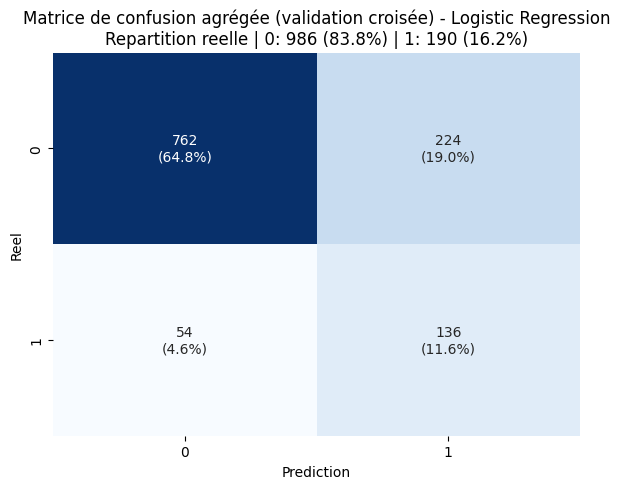


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.85       986
         1.0       0.38      0.72      0.49       190

    accuracy                           0.76      1176
   macro avg       0.66      0.74      0.67      1176
weighted avg       0.84      0.76      0.79      1176


Linear SVC
Train | Accuracy: 0.7942 +/- 0.0053 | Precision: 0.4266 +/- 0.0076 | Recall: 0.7934 +/- 0.0175 | F1: 0.5547 +/- 0.0078 | ROC AUC: 0.8842 +/- 0.0071 | PR-AUC: 0.6871 +/- 0.0284
Test  | Accuracy: 0.7577 +/- 0.0197 | Precision: 0.3686 +/- 0.0326 | Recall: 0.7053 +/- 0.0947 | F1: 0.4833 +/- 0.0477 | ROC AUC: 0.8129 +/- 0.0426 | PR-AUC: 0.5860 +/- 0.0771
Temps | Total CV: 0.3876s | Moyenne par fold: 0.0294s +/- 0.0025s


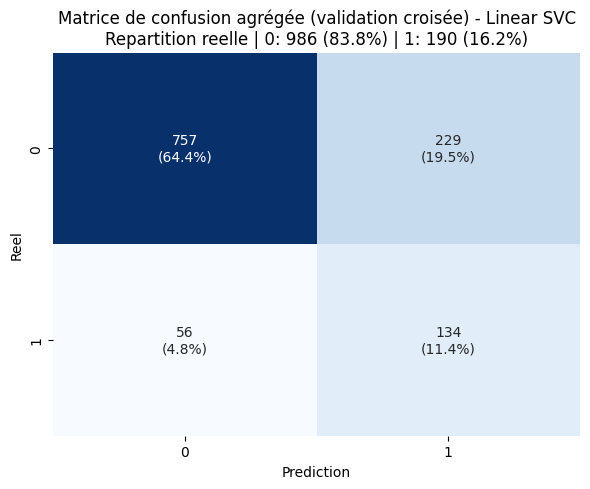


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.84       986
         1.0       0.37      0.71      0.48       190

    accuracy                           0.76      1176
   macro avg       0.65      0.74      0.66      1176
weighted avg       0.84      0.76      0.78      1176


SVC
Train | Accuracy: 0.9486 +/- 0.0042 | Precision: 0.7742 +/- 0.0176 | Recall: 0.9632 +/- 0.0067 | F1: 0.8583 +/- 0.0097 | ROC AUC: 0.9928 +/- 0.0008 | PR-AUC: 0.9691 +/- 0.0041
Test  | Accuracy: 0.8512 +/- 0.0231 | Precision: 0.5375 +/- 0.0577 | Recall: 0.5737 +/- 0.1205 | F1: 0.5504 +/- 0.0797 | ROC AUC: 0.8044 +/- 0.0456 | PR-AUC: 0.5909 +/- 0.0738
Temps | Total CV: 2.9496s | Moyenne par fold: 0.4296s +/- 0.0431s


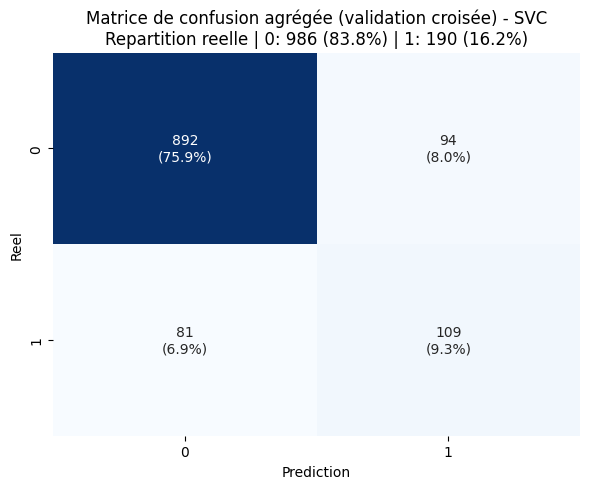


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.92      0.90      0.91       986
         1.0       0.54      0.57      0.55       190

    accuracy                           0.85      1176
   macro avg       0.73      0.74      0.73      1176
weighted avg       0.86      0.85      0.85      1176


KNeighbors Classifier
Train | Accuracy: 0.8767 +/- 0.0029 | Precision: 0.8515 +/- 0.0180 | Recall: 0.2868 +/- 0.0175 | F1: 0.4289 +/- 0.0205 | ROC AUC: 0.9114 +/- 0.0059 | PR-AUC: 0.6080 +/- 0.0157
Test  | Accuracy: 0.8469 +/- 0.0096 | Precision: 0.6144 +/- 0.1248 | Recall: 0.1474 +/- 0.0268 | F1: 0.2375 +/- 0.0434 | ROC AUC: 0.6894 +/- 0.0338 | PR-AUC: 0.3320 +/- 0.0254
Temps | Total CV: 4.6860s | Moyenne par fold: 0.8941s +/- 1.7479s


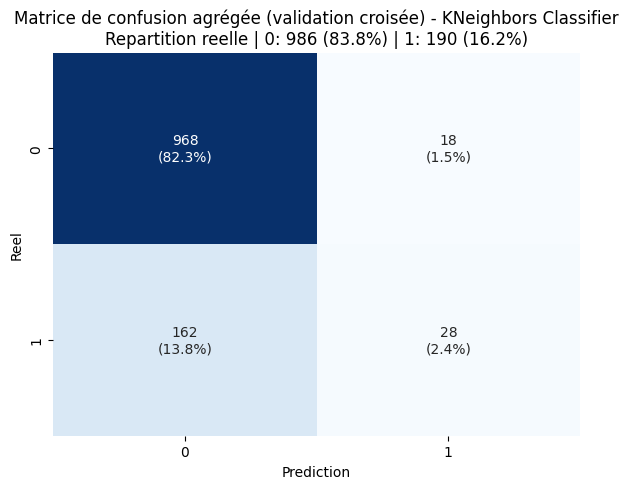


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91       986
         1.0       0.61      0.15      0.24       190

    accuracy                           0.85      1176
   macro avg       0.73      0.56      0.58      1176
weighted avg       0.82      0.85      0.81      1176


Decision Tree
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.7763 +/- 0.0204 | Precision: 0.3151 +/- 0.0559 | Recall: 0.3263 +/- 0.0657 | F1: 0.3199 +/- 0.0583 | ROC AUC: 0.5947 +/- 0.0367 | PR-AUC: 0.2149 +/- 0.0289
Temps | Total CV: 0.3344s | Moyenne par fold: 0.0302s +/- 0.0192s


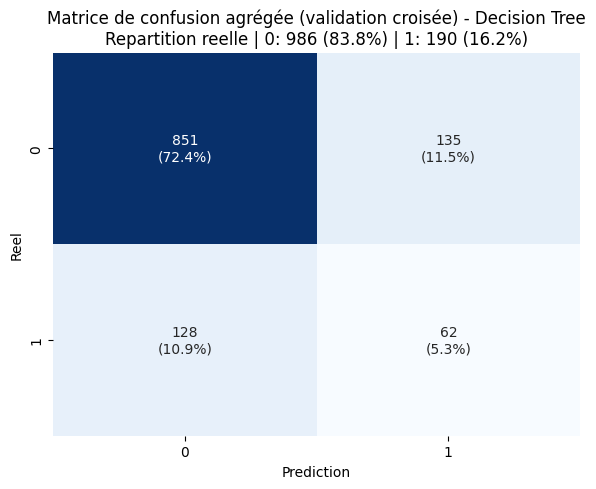


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.87       986
         1.0       0.31      0.33      0.32       190

    accuracy                           0.78      1176
   macro avg       0.59      0.59      0.59      1176
weighted avg       0.78      0.78      0.78      1176


Random Forest
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8554 +/- 0.0039 | Precision: 0.8414 +/- 0.0862 | Recall: 0.1316 +/- 0.0235 | F1: 0.2264 +/- 0.0349 | ROC AUC: 0.7843 +/- 0.0415 | PR-AUC: 0.5215 +/- 0.0338
Temps | Total CV: 1.6355s | Moyenne par fold: 0.2677s +/- 0.0258s


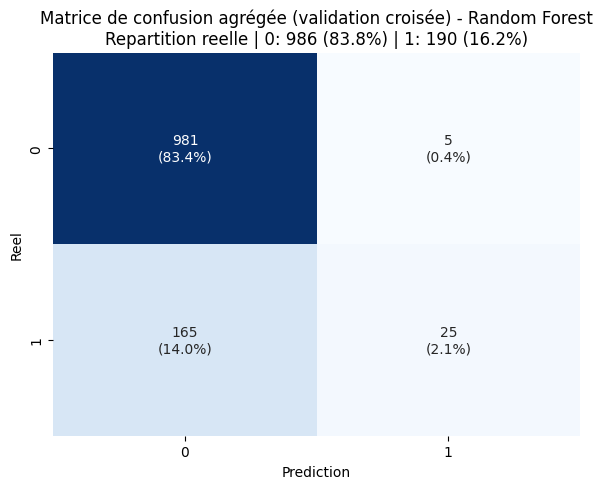


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       986
         1.0       0.83      0.13      0.23       190

    accuracy                           0.86      1176
   macro avg       0.84      0.56      0.57      1176
weighted avg       0.85      0.86      0.81      1176


Extra Trees
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8588 +/- 0.0042 | Precision: 0.8620 +/- 0.0777 | Recall: 0.1526 +/- 0.0307 | F1: 0.2575 +/- 0.0439 | ROC AUC: 0.7895 +/- 0.0594 | PR-AUC: 0.5268 +/- 0.0677
Temps | Total CV: 1.4697s | Moyenne par fold: 0.2368s +/- 0.0153s


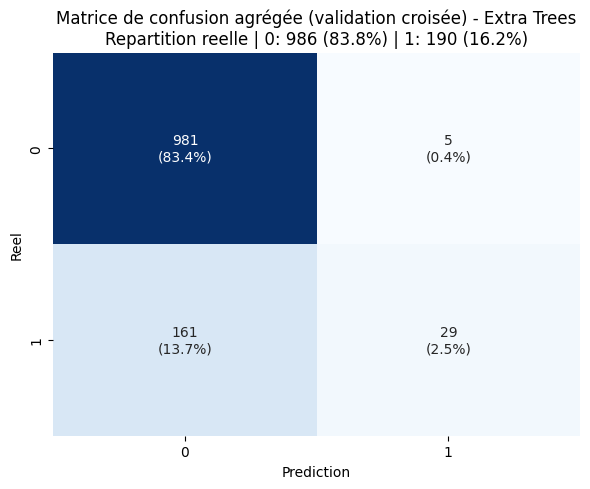


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       986
         1.0       0.85      0.15      0.26       190

    accuracy                           0.86      1176
   macro avg       0.86      0.57      0.59      1176
weighted avg       0.86      0.86      0.81      1176


Gradient Boosting
Train | Accuracy: 0.9653 +/- 0.0040 | Precision: 0.9967 +/- 0.0041 | Recall: 0.7882 +/- 0.0233 | F1: 0.8801 +/- 0.0150 | ROC AUC: 0.9949 +/- 0.0024 | PR-AUC: 0.9815 +/- 0.0063
Test  | Accuracy: 0.8648 +/- 0.0082 | Precision: 0.7098 +/- 0.0787 | Recall: 0.2895 +/- 0.0577 | F1: 0.4058 +/- 0.0539 | ROC AUC: 0.7811 +/- 0.0426 | PR-AUC: 0.5145 +/- 0.0488
Temps | Total CV: 2.2581s | Moyenne par fold: 0.4229s +/- 0.0319s


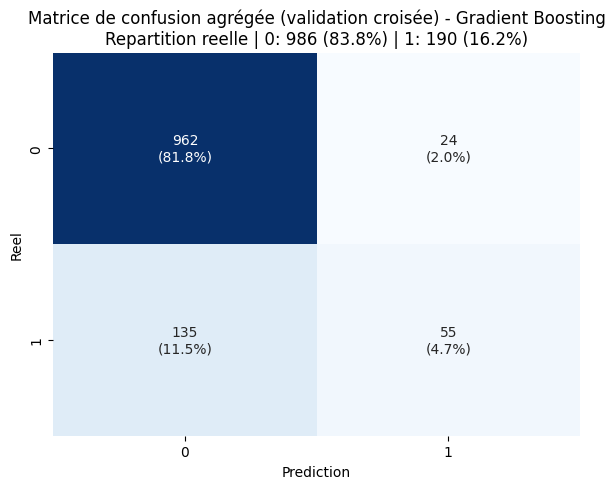


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92       986
         1.0       0.70      0.29      0.41       190

    accuracy                           0.86      1176
   macro avg       0.79      0.63      0.67      1176
weighted avg       0.85      0.86      0.84      1176


AdaBoost
Train | Accuracy: 0.8880 +/- 0.0075 | Precision: 0.8499 +/- 0.0364 | Recall: 0.3724 +/- 0.0453 | F1: 0.5164 +/- 0.0473 | ROC AUC: 0.8969 +/- 0.0133 | PR-AUC: 0.7053 +/- 0.0354
Test  | Accuracy: 0.8699 +/- 0.0107 | Precision: 0.7675 +/- 0.1289 | Recall: 0.3053 +/- 0.0357 | F1: 0.4306 +/- 0.0259 | ROC AUC: 0.7961 +/- 0.0483 | PR-AUC: 0.5528 +/- 0.0505
Temps | Total CV: 1.0002s | Moyenne par fold: 0.1591s +/- 0.0093s


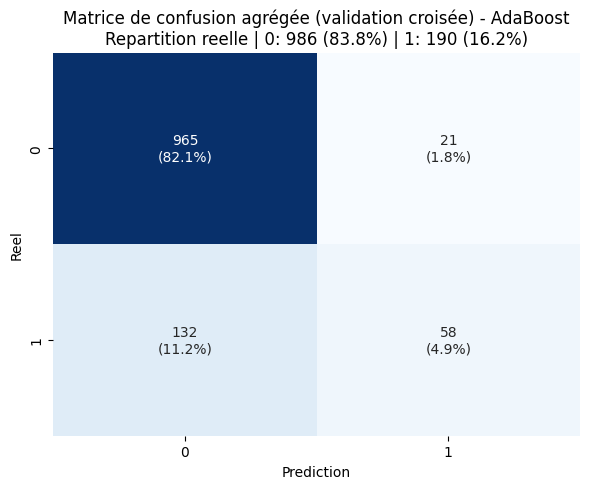


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93       986
         1.0       0.73      0.31      0.43       190

    accuracy                           0.87      1176
   macro avg       0.81      0.64      0.68      1176
weighted avg       0.86      0.87      0.85      1176



In [3]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            random_state=42,
            class_weight="balanced"
        )),
    ]),

    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            random_state=42,
            dual="auto",
            max_iter=5000,
            class_weight="balanced"
        )),
    ]),

    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42,
            class_weight="balanced"
        )),
    ]),

    "KNeighbors Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42,
    ),
}


for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(model=model,X=X_model,y=y_model,cv=5,stratify=True,model_name=name,)


Logistic Regression + SMOTE
Train | Accuracy: 0.8080 +/- 0.0066 | Precision: 0.4463 +/- 0.0109 | Recall: 0.7789 +/- 0.0135 | F1: 0.5674 +/- 0.0112 | ROC AUC: 0.8795 +/- 0.0060 | PR-AUC: 0.6851 +/- 0.0260
Test  | Accuracy: 0.7755 +/- 0.0243 | Precision: 0.3883 +/- 0.0420 | Recall: 0.6789 +/- 0.0990 | F1: 0.4931 +/- 0.0573 | ROC AUC: 0.8120 +/- 0.0444 | PR-AUC: 0.5907 +/- 0.0709
Temps | Total CV: 0.3350s | Moyenne par fold: 0.0393s +/- 0.0129s


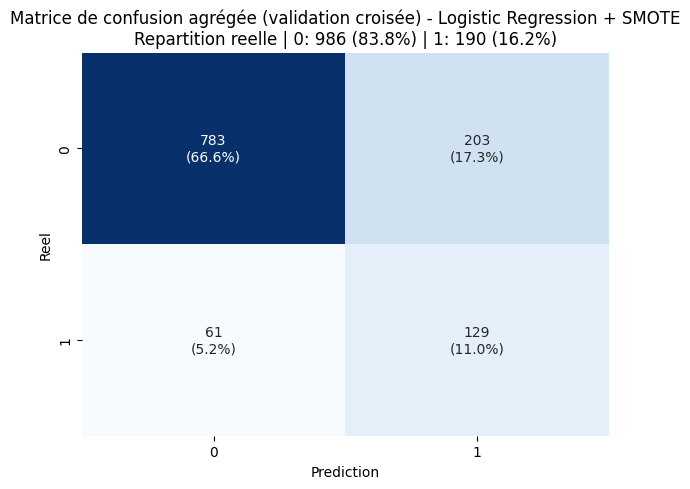


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.93      0.79      0.86       986
         1.0       0.39      0.68      0.49       190

    accuracy                           0.78      1176
   macro avg       0.66      0.74      0.67      1176
weighted avg       0.84      0.78      0.80      1176


SVC RBF + SMOTE
Train | Accuracy: 0.9764 +/- 0.0027 | Precision: 0.8964 +/- 0.0127 | Recall: 0.9658 +/- 0.0134 | F1: 0.9297 +/- 0.0080 | ROC AUC: 0.9954 +/- 0.0019 | PR-AUC: 0.9827 +/- 0.0060
Test  | Accuracy: 0.8478 +/- 0.0129 | Precision: 0.5448 +/- 0.0556 | Recall: 0.4158 +/- 0.0586 | F1: 0.4675 +/- 0.0385 | ROC AUC: 0.7685 +/- 0.0528 | PR-AUC: 0.5116 +/- 0.0522
Temps | Total CV: 3.2613s | Moyenne par fold: 0.5157s +/- 0.0457s


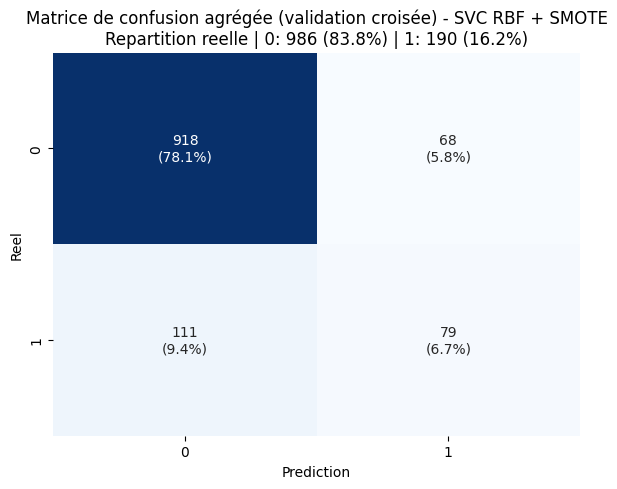


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91       986
         1.0       0.54      0.42      0.47       190

    accuracy                           0.85      1176
   macro avg       0.71      0.67      0.69      1176
weighted avg       0.83      0.85      0.84      1176



In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "Logistic Regression + SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),

    "SVC RBF + SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", SVC(kernel="rbf", probability=True, random_state=42)),
    ]),
}

for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(
        model=model,
        X=X_model,
        y=y_model,
        cv=5,
        stratify=True,
        model_name=name,
    )

Au vu des premiers résultats, nous retenons pour la suite trois candidats à comparer plus finement :  
- la régression logistique, solide sur le rappel ;  
- le SVC, meilleur compromis global en F1 parmi les modèles testés ;  
- AdaBoost, conservé comme point de comparaison côté ensemble.  

Cette sélection permet de comparer des approches de nature différente, d’en optimiser les paramètres, puis d’en analyser les performances et l’interprétabilité avant de retenir un modèle final.

Le réglage du seuil intervient après l’optimisation des hyperparamètres, car ces derniers modifient les scores prédits par le modèle et peuvent donc déplacer le seuil optimal.  
Il est donc plus rigoureux d’optimiser d’abord les modèles présélectionnés, puis d’ajuster le seuil sur la version finale retenue.


In [5]:
import importlib
import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

# 1. Logistic Regression
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs"],
}

logreg_results = Fonctions_MODEL.optimize_classification_hyperparameters(
    model=logreg_model,
    param_grid=logreg_param_grid,
    X=X_model,
    y=y_model,
    cv=5,
    scoring="f1",
    stratify=True,
    search_type="grid",
    model_name="Logistic Regression",
)



Logistic Regression
GridSearchCV | Scoring : f1 | Meilleur score CV : 0.5545
Meilleurs hyperparametres : {'model__C': 10, 'model__class_weight': None, 'model__solver': 'lbfgs'}


In [7]:
# 2. SVC
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        random_state=42
    )),
])

svc_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf", "poly", "sigmoid"],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "model__degree": [2, 3, 4, 5],
    "model__class_weight": [None, "balanced"],
}

svc_results = Fonctions_MODEL.optimize_classification_hyperparameters(
    model=svc_model,
    param_grid=svc_param_grid,
    X=X_model,
    y=y_model,
    cv=5,
    scoring="f1",
    stratify=True,
    search_type="random",
    n_iter=20,
    model_name="SVC",
)



SVC
RandomizedSearchCV | Scoring : f1 | Meilleur score CV : 0.5643
Meilleurs hyperparametres : {'model__kernel': 'linear', 'model__gamma': 0.01, 'model__degree': 2, 'model__class_weight': None, 'model__C': 1}


In [8]:
# 3. AdaBoost
ada_model = AdaBoostClassifier(random_state=42)

ada_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

ada_results = Fonctions_MODEL.optimize_classification_hyperparameters(
    model=ada_model,
    param_grid=ada_param_grid,
    X=X_model,
    y=y_model,
    cv=5,
    scoring="f1",
    stratify=True,
    search_type="grid",
    model_name="AdaBoost",
)


AdaBoost
GridSearchCV | Scoring : f1 | Meilleur score CV : 0.5148
Meilleurs hyperparametres : {'learning_rate': 1.0, 'n_estimators': 200}


Faisons maintenant le travail de réglage du seuil sur les modèles retenus :


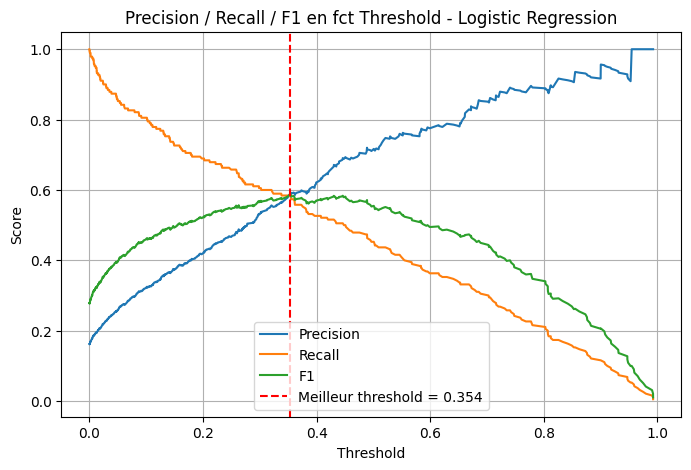

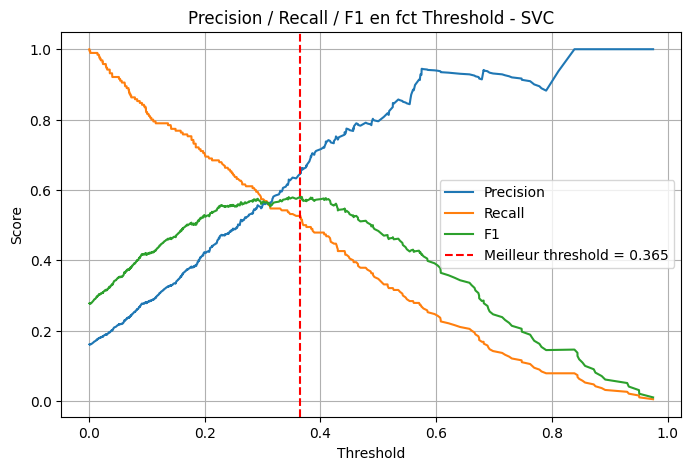

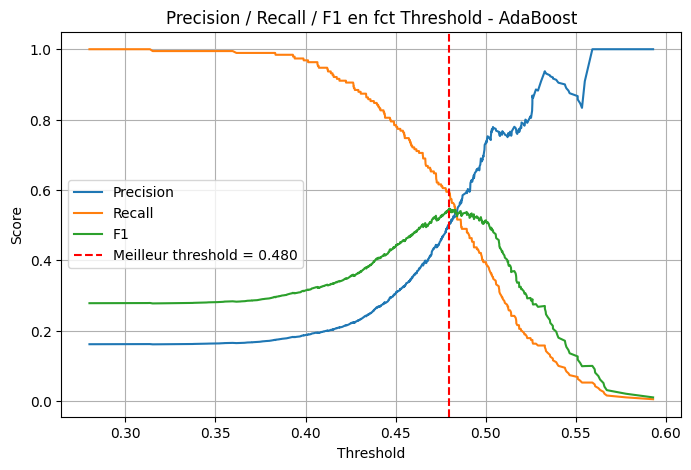

,Best Threshold,Precision,Recall,F1
Logistic Regression,0.353569,0.593583,0.584211,0.588859
SVC,0.365419,0.649351,0.526316,0.581395
AdaBoost,0.479788,0.506726,0.594737,0.547215


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (precision_recall_curve,precision_score,recall_score,f1_score,)

models_phase_ada = {
    "Logistic Regression": logreg_results["Best Estimator"],
    "SVC": svc_results["Best Estimator"],
    "AdaBoost": ada_results["Best Estimator"],
}


threshold_registry = {}

def get_oof_scores(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    if hasattr(model, "predict_proba"):
        scores = cross_val_predict(
            clone(model),
            X,
            y,
            cv=skf,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]
    else:
        scores = cross_val_predict(
            clone(model),
            X,
            y,
            cv=skf,
            method="decision_function",
            n_jobs=-1
        )

    return scores

def tune_threshold_cv(model, X, y, model_name="", cv=5, plot_curve=True):
    oof_scores = get_oof_scores(model, X, y, cv=cv)

    precisions, recalls, thresholds = precision_recall_curve(y, oof_scores)

    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-12)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    y_pred_best = (oof_scores >= best_threshold).astype(int)

    results = {
        "Model": model_name,
        "Best Threshold": best_threshold,
        "Precision": precision_score(y, y_pred_best, zero_division=0),
        "Recall": recall_score(y, y_pred_best, zero_division=0),
        "F1": f1_score(y, y_pred_best, zero_division=0),
        "OOF Scores": oof_scores,
        "Thresholds": thresholds,
        "Precisions": precisions[:-1],
        "Recalls": recalls[:-1],
        "F1 Scores": f1_scores,
    }

    if plot_curve:
        plt.figure(figsize=(8, 5))
        plt.plot(thresholds, precisions[:-1], label="Precision")
        plt.plot(thresholds, recalls[:-1], label="Recall")
        plt.plot(thresholds, f1_scores, label="F1")
        plt.axvline(best_threshold, color="red", linestyle="--", label=f"Meilleur threshold = {best_threshold:.3f}")
        plt.xlabel("Threshold")
        plt.ylabel("Score")
        plt.title(f"Precision / Recall / F1 en fct Threshold - {model_name}")
        plt.legend()
        plt.grid(True)
        plt.show()


    return results

threshold_results_ada_phase = {}
for name, model in models_phase_ada.items():
    threshold_results_ada_phase[name] = tune_threshold_cv(model=model,X=X_model,y=y_model,model_name=name,cv=5,plot_curve=True,)

threshold_registry["phase_ada"] = threshold_results_ada_phase

pd.DataFrame({
    name: {
        "Best Threshold": res["Best Threshold"],
        "Precision": res["Precision"],
        "Recall": res["Recall"],
        "F1": res["F1"],
    }
    for name, res in threshold_results_ada_phase.items()
}).T


Le réglage du seuil confirme que **la régression logistique** conserve le meilleur F1 sur ce split de validation, tandis que **le SVC** se distingue surtout par une précision plus élevée.  

Sur ce split de validation :  
- **Logistic Regression** : seuil = 0.3536, précision = 0.5936, rappel = 0.5842, F1 = 0.5889.  
- **SVC** : seuil = 0.3654, précision = 0.6494, rappel = 0.5263, F1 = 0.5814.  
- **AdaBoost** : seuil = 0.4798, précision = 0.5067, rappel = 0.5947, F1 = 0.5472.  

Dans ce contexte, nous retenons **la régression logistique** et **le SVC linéaire** pour la suite de l’analyse : le premier pour son meilleur équilibre global, le second pour son profil plus précis à seuil optimisé.


,Variable,Coefficient,Abs_Coefficient
30,mediane_revenu_par_niveau,1.691836,1.691836
16,revenu_mensuel_log,-1.241455,1.241455
19,annees_dans_le_poste_actuel_log,0.866266,0.866266
10,heure_supplementaires,0.848381,0.848381
23,ratio_anciennete_poste,-0.661301,0.661301
34,revenu_par_poste,-0.630181,0.630181
2,nombre_experiences_precedentes,0.613014,0.613014
3,satisfaction_employee_environnement,-0.575980,0.575980
21,annes_sous_responsable_actuel_log,-0.574327,0.574327
20,annees_depuis_la_derniere_promotion_log,0.538684,0.538684


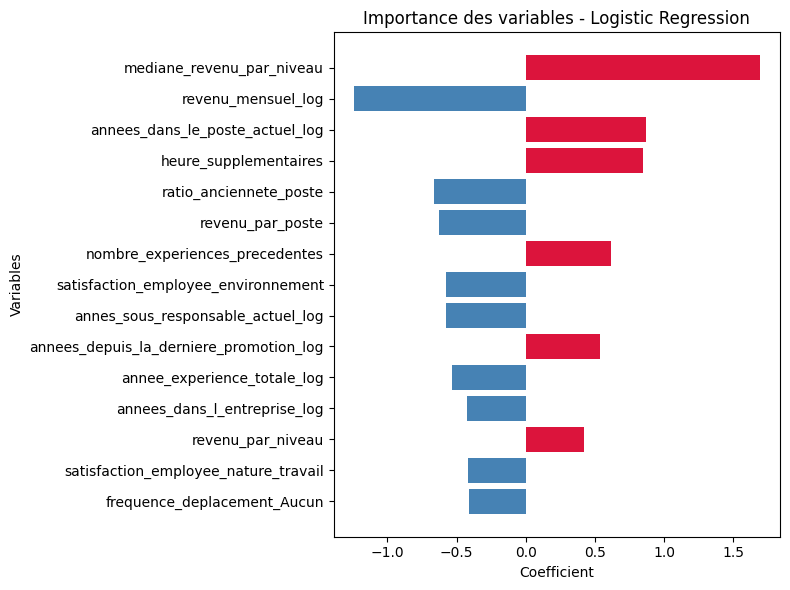

In [10]:
logreg_best = logreg_results["Best Estimator"]
logreg_best.fit(X_model, y_model)

coef_df = pd.DataFrame({
    "Variable": X_model.columns,
    "Coefficient": logreg_best.named_steps["model"].coef_[0],
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

display(coef_df.head(15))

top_coef = coef_df.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
colors = ["crimson" if c > 0 else "steelblue" for c in top_coef["Coefficient"]]

plt.barh(top_coef["Variable"], top_coef["Coefficient"], color=colors)
plt.title("Importance des variables - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


,Variable,Importance
30,mediane_revenu_par_niveau,1.071294
16,revenu_mensuel_log,0.981130
10,heure_supplementaires,0.564737
20,annees_depuis_la_derniere_promotion_log,0.495618
18,annees_dans_l_entreprise_log,0.435404
19,annees_dans_le_poste_actuel_log,0.400324
2,nombre_experiences_precedentes,0.393651
3,satisfaction_employee_environnement,0.349895
21,annes_sous_responsable_actuel_log,0.321492
23,ratio_anciennete_poste,0.320261


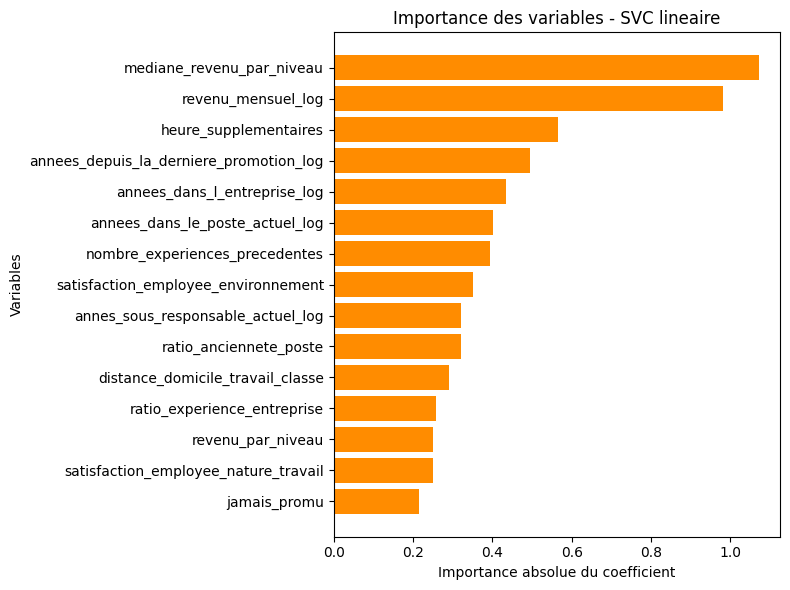

In [11]:
svc_best = svc_results["Best Estimator"]
svc_best.fit(X_model, y_model)

svc_model = svc_best.named_steps["model"]

svc_importance = pd.DataFrame({
    "Variable": X_model.columns,
    "Importance": np.abs(svc_model.coef_[0]),
}).sort_values("Importance", ascending=False)

display(svc_importance.head(15))

top_svc = svc_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_svc["Variable"], top_svc["Importance"], color="darkorange")
plt.title("Importance des variables - SVC lineaire")
plt.xlabel("Importance absolue du coefficient")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


**La régression logistique** met en avant, dans les coefficients absolus, un noyau de variables dominantes autour de :  
- `mediane_revenu_par_niveau` ;  
- `revenu_mensuel_log` ;  
- `annees_dans_le_poste_actuel_log` ;  
- `heure_supplementaires` ;  
- ainsi que plusieurs variables d’ancienneté et de progression interne.  

**Le SVC linéaire** fait ressortir un profil très proche :  
- `mediane_revenu_par_niveau`, `revenu_mensuel_log`, `heure_supplementaires` ;  
- puis des variables de carrière comme `annees_depuis_la_derniere_promotion_log`, `annees_dans_l_entreprise_log` et `ratio_anciennete_poste`.  

Les deux modèles convergent donc sur un socle commun centré sur la rémunération, les heures supplémentaires et la dynamique de carrière.


,Variable,Importance Moyenne,Ecart-Type
16,revenu_mensuel_log,0.268345,0.047727
10,heure_supplementaires,0.170608,0.054895
21,annes_sous_responsable_actuel_log,0.139597,0.031441
23,ratio_anciennete_poste,0.112240,0.045781
49,poste_regroupe_Consultant,0.108878,0.016274
17,annee_experience_totale_log,0.105536,0.027275
18,annees_dans_l_entreprise_log,0.081953,0.026701
2,nombre_experiences_precedentes,0.073629,0.025800
30,mediane_revenu_par_niveau,0.067113,0.031308
37,statut_marital_Célibataire,0.061744,0.020809


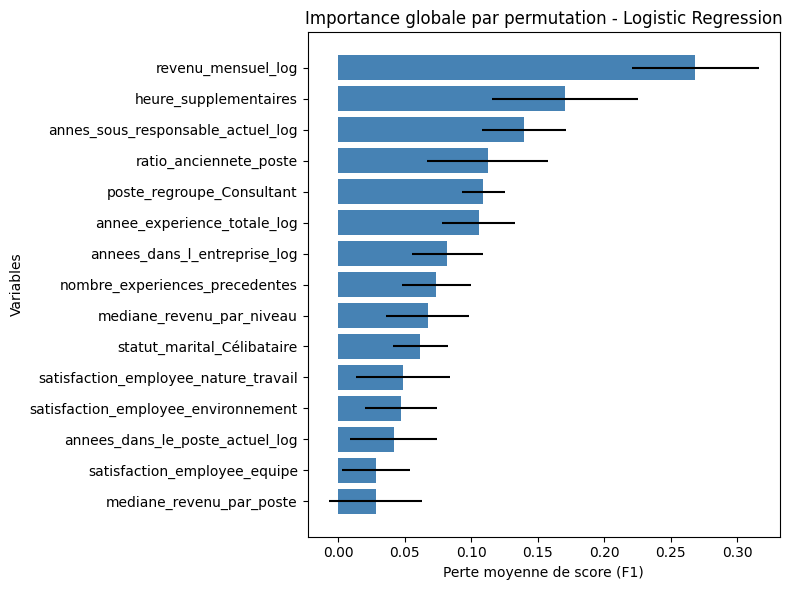

In [12]:
from sklearn.inspection import permutation_importance

X_train_pr, X_valid_pr, y_train_pr, y_valid_pr = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

logreg_best = logreg_results["Best Estimator"]
logreg_best.fit(X_train_pr, y_train_pr)

perm = permutation_importance(
    logreg_best,
    X_valid_pr,
    y_valid_pr,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_importance = pd.DataFrame({
    "Variable": X_valid_pr.columns,
    "Importance Moyenne": perm.importances_mean,
    "Ecart-Type": perm.importances_std,
}).sort_values("Importance Moyenne", ascending=False)

display(perm_importance.head(15))

top_perm_importance = perm_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    top_perm_importance["Variable"],
    top_perm_importance["Importance Moyenne"],
    xerr=top_perm_importance["Ecart-Type"],
    color="steelblue",
)
plt.title("Importance globale par permutation - Logistic Regression")
plt.xlabel("Perte moyenne de score (F1)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


,Variable,Importance Moyenne,Ecart-Type
16,revenu_mensuel_log,0.316300,0.055453
10,heure_supplementaires,0.216119,0.050443
18,annees_dans_l_entreprise_log,0.179618,0.035345
23,ratio_anciennete_poste,0.159461,0.034283
21,annes_sous_responsable_actuel_log,0.158297,0.038685
5,niveau_hierarchique_poste,0.140707,0.029955
17,annee_experience_totale_log,0.132305,0.035532
30,mediane_revenu_par_niveau,0.127208,0.035515
2,nombre_experiences_precedentes,0.124234,0.029788
3,satisfaction_employee_environnement,0.089563,0.034123


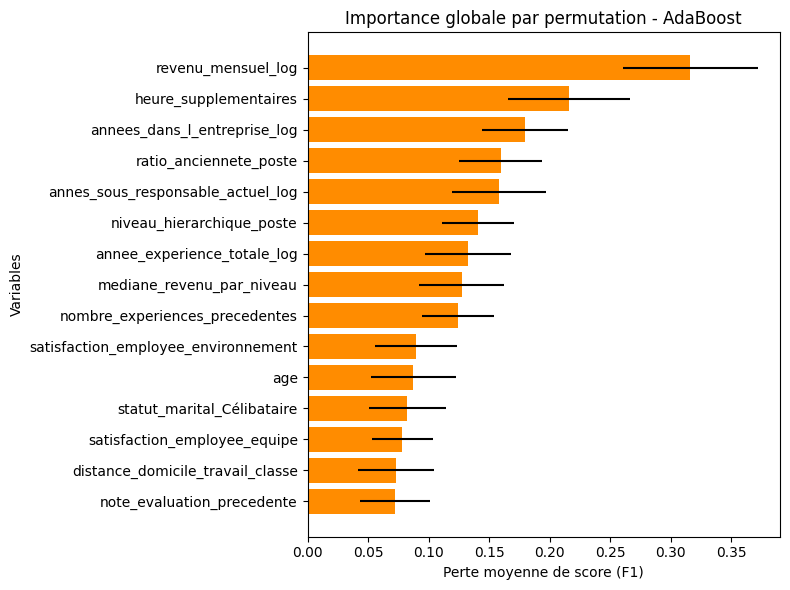

In [13]:
from sklearn.inspection import permutation_importance

svc_best = svc_results["Best Estimator"]
svc_best.fit(X_train_pr, y_train_pr)

perm = permutation_importance(svc_best,X_valid_pr,y_valid_pr,scoring="f1",n_repeats=10,random_state=42,n_jobs=-1,)

perm_importance = pd.DataFrame({
    "Variable": X_valid_pr.columns,
    "Importance Moyenne": perm.importances_mean,
    "Ecart-Type": perm.importances_std,
}).sort_values("Importance Moyenne", ascending=False)

display(perm_importance.head(15))

top_perm_importance = perm_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    top_perm_importance["Variable"],
    top_perm_importance["Importance Moyenne"],
    xerr=top_perm_importance["Ecart-Type"],
    color="darkorange",
)
plt.title("Importance globale par permutation - AdaBoost")
plt.xlabel("Perte moyenne de score (F1)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()



La permutation importance confirme une convergence partielle entre les deux modèles, avec quelques différences de hiérarchie.  

- **Logistic Regression** : `revenu_mensuel_log` arrive en tête, suivi de `heure_supplementaires`, puis de variables d’ancienneté et de position (`annes_sous_responsable_actuel_log`, `ratio_anciennete_poste`, `annee_experience_totale_log`).  
- **SVC linéaire** : `revenu_mensuel_log` reste également la variable la plus influente, devant `heure_supplementaires`, `annees_dans_l_entreprise_log`, `ratio_anciennete_poste` et `niveau_hierarchique_poste`.  

Cette lecture conforte la robustesse des facteurs métiers majeurs, tout en montrant que le SVC accorde un peu plus de poids à la position hiérarchique et à l’ancienneté globale.


c:\Users\kevin\Desktop\FORMATION AI\01_FORMATION AI ENGINEER\02_PROJETS\04_PROJET 04\01_PREPARATION\PROJET 4\PROJET-4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


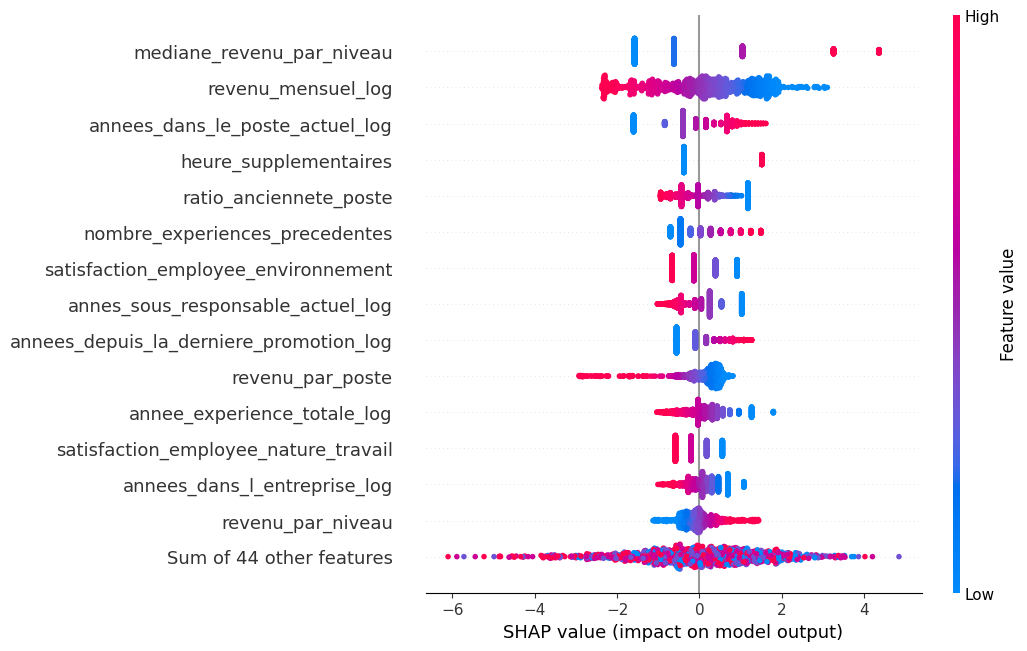

In [14]:
import shap
import pandas as pd

logreg_best = logreg_results["Best Estimator"]
logreg_best.fit(X_model, y_model)

# Recuperation du scaler et du modele lineaire
scaler = logreg_best.named_steps["scaler"]
linear_model = logreg_best.named_steps["model"]

# Transformation + reconstruction en DataFrame pour garder les noms de colonnes
X_model_scaled = pd.DataFrame(
    scaler.transform(X_model),
    columns=X_model.columns,
    index=X_model.index,
)

explainer = shap.LinearExplainer(linear_model, X_model_scaled)
shap_values = explainer(X_model_scaled)

shap.plots.beeswarm(shap_values, max_display=15)


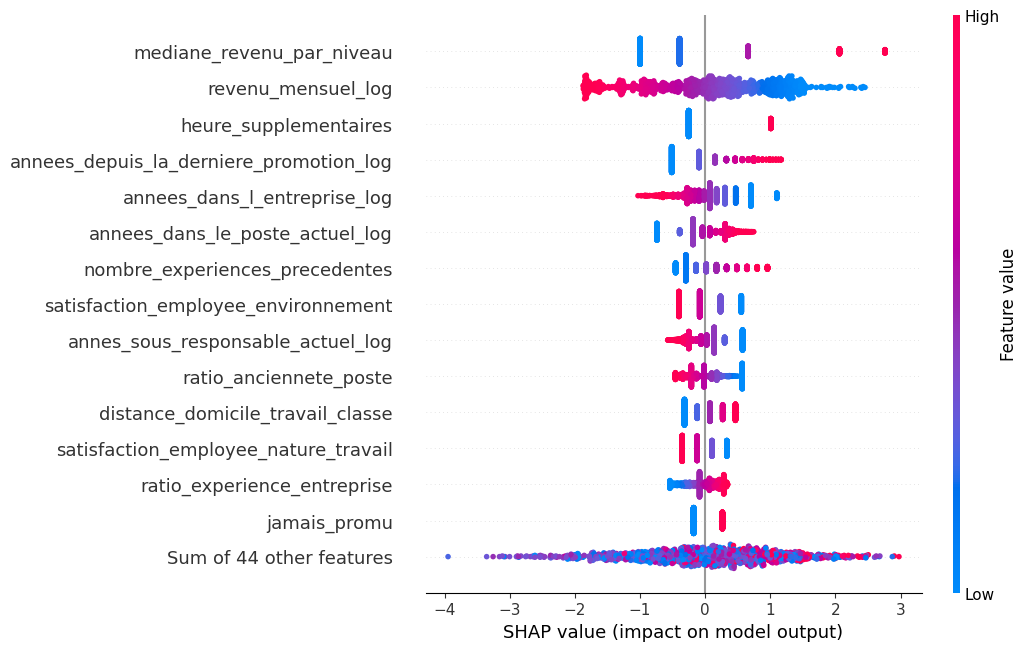

In [15]:
svc_best = svc_results["Best Estimator"]
svc_best.fit(X_model, y_model)

scaler = svc_best.named_steps["scaler"]
svc_model = svc_best.named_steps["model"]

X_model_scaled = pd.DataFrame(
    scaler.transform(X_model),
    columns=X_model.columns,
    index=X_model.index,
)

if svc_model.kernel == "linear":
    explainer = shap.LinearExplainer(svc_model, X_model_scaled)
    shap_values = explainer(X_model_scaled)
else:
    background = shap.sample(X_model_scaled, 100, random_state=42)
    sample_to_explain = shap.sample(X_model_scaled, 200, random_state=42)

    explainer = shap.KernelExplainer(svc_model.predict_proba, background)
    shap_values = explainer.shap_values(sample_to_explain)

    shap_values = shap.Explanation(
        values=shap_values[1],
        base_values=explainer.expected_value[1],
        data=sample_to_explain,
        feature_names=sample_to_explain.columns.tolist()
    )

shap.plots.beeswarm(shap_values, max_display=15)


Les analyses SHAP montrent une bonne cohérence globale entre les deux approches linéaires, avec des facteurs récurrents liés :  
- aux heures supplémentaires ;  
- à l’expérience et à l’ancienneté ;  
- à la rémunération ;  
- et à certaines dimensions de satisfaction ou de mobilité.  

La régression logistique et le SVC linéaire racontent donc une histoire globalement cohérente, avec des écarts surtout dans l’intensité relative accordée à certains signaux.


Nb pred 1 disponibles : 120
Nb pred 0 disponibles : 1056
Indices pred 1 : [414, 1153, 122]
Indices pred 0 : [141, 149, 1208]

Observation predite = 1 | index = 414
Base value (log-odds) : -1.8933
Base value (proba)    : 0.1309
f(x) final            : 0.5701
Proba pipeline        : 0.7675
Proba SHAP            : 0.6388
Seuil 0.5             : classe 1


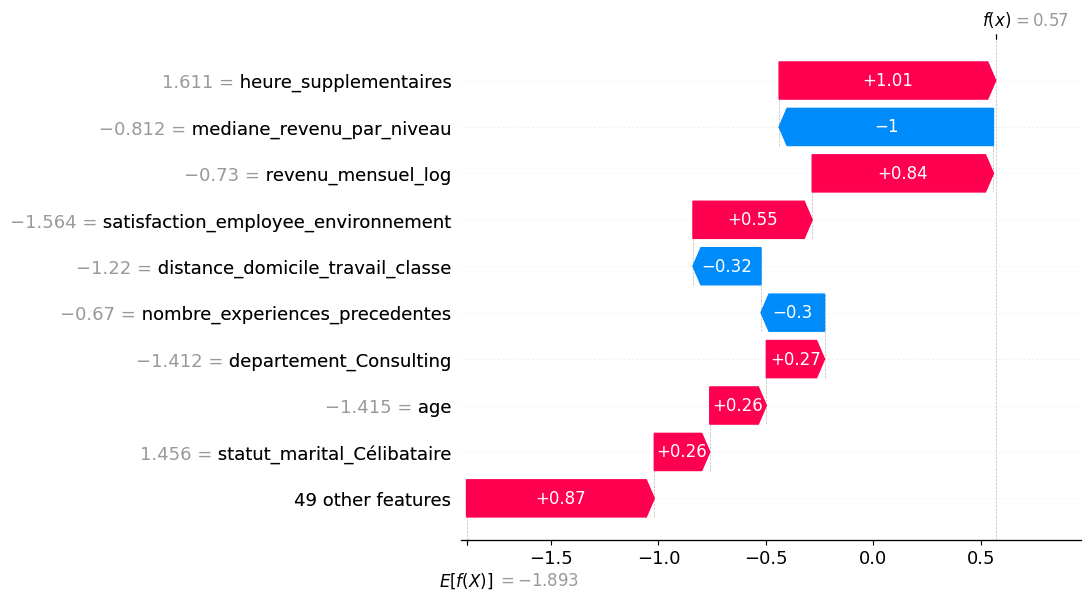


Observation predite = 1 | index = 1153
Base value (log-odds) : -1.8933
Base value (proba)    : 0.1309
f(x) final            : 1.6738
Proba pipeline        : 0.9468
Proba SHAP            : 0.8421
Seuil 0.5             : classe 1


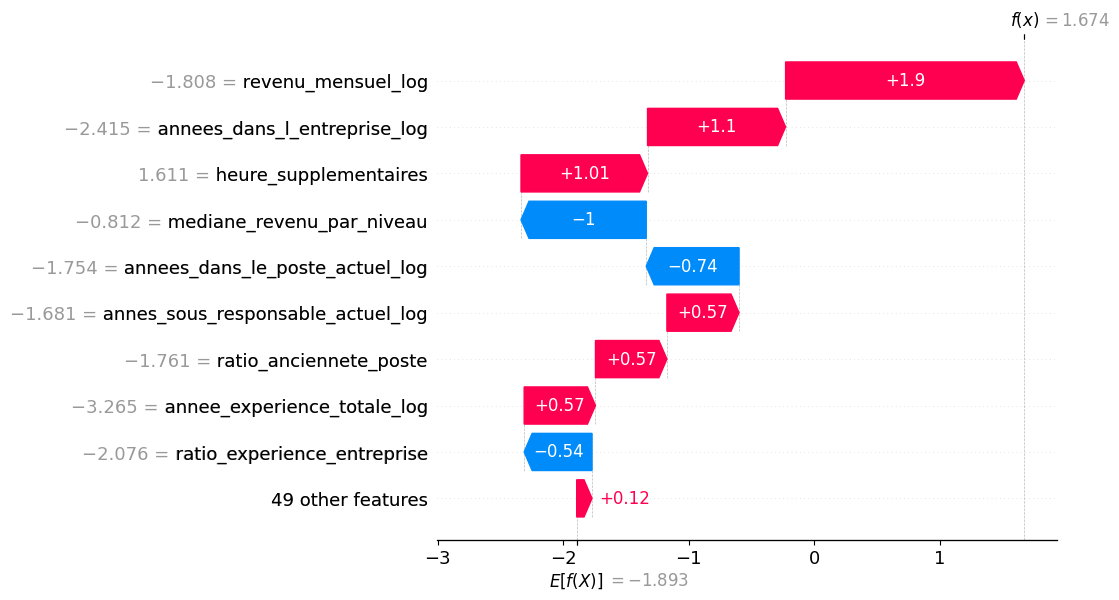


Observation predite = 1 | index = 122
Base value (log-odds) : -1.8933
Base value (proba)    : 0.1309
f(x) final            : 0.3375
Proba pipeline        : 0.6520
Proba SHAP            : 0.5836
Seuil 0.5             : classe 1


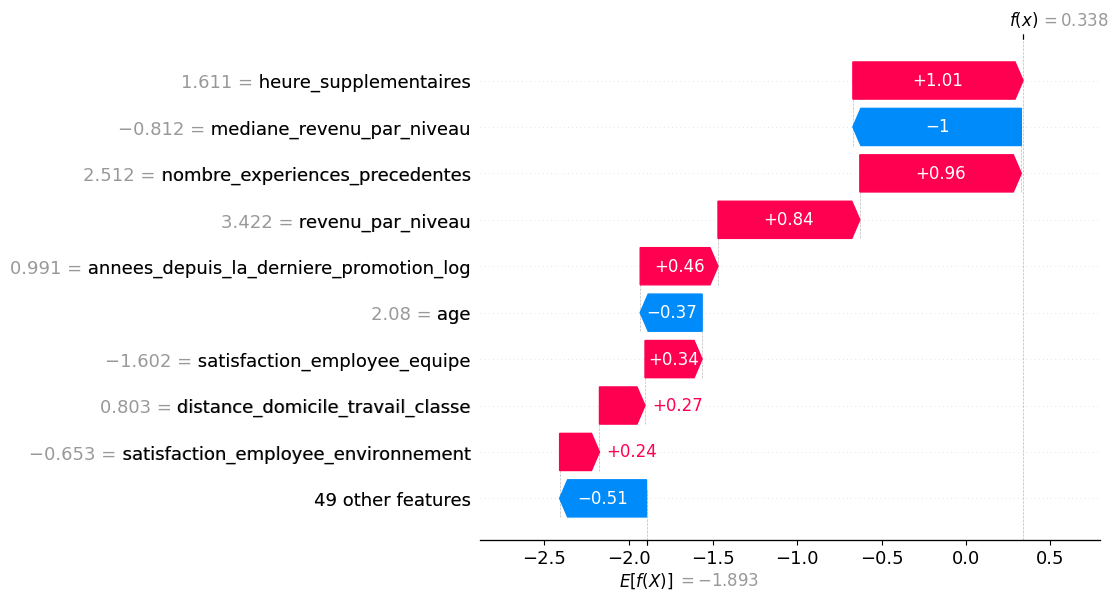


Observation predite = 0 | index = 141
Base value (log-odds) : -1.8933
Base value (proba)    : 0.1309
f(x) final            : -1.7259
Proba pipeline        : 0.1131
Proba SHAP            : 0.1511
Seuil 0.5             : classe 0


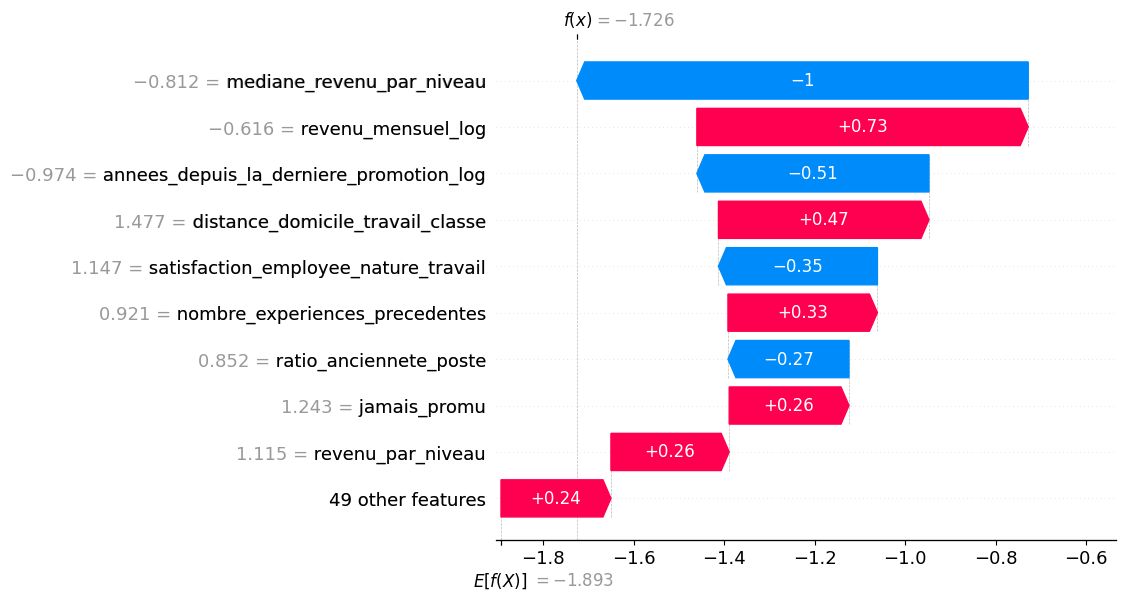


Observation predite = 0 | index = 149
Base value (log-odds) : -1.8933
Base value (proba)    : 0.1309
f(x) final            : -0.2079
Proba pipeline        : 0.4277
Proba SHAP            : 0.4482
Seuil 0.5             : classe 0


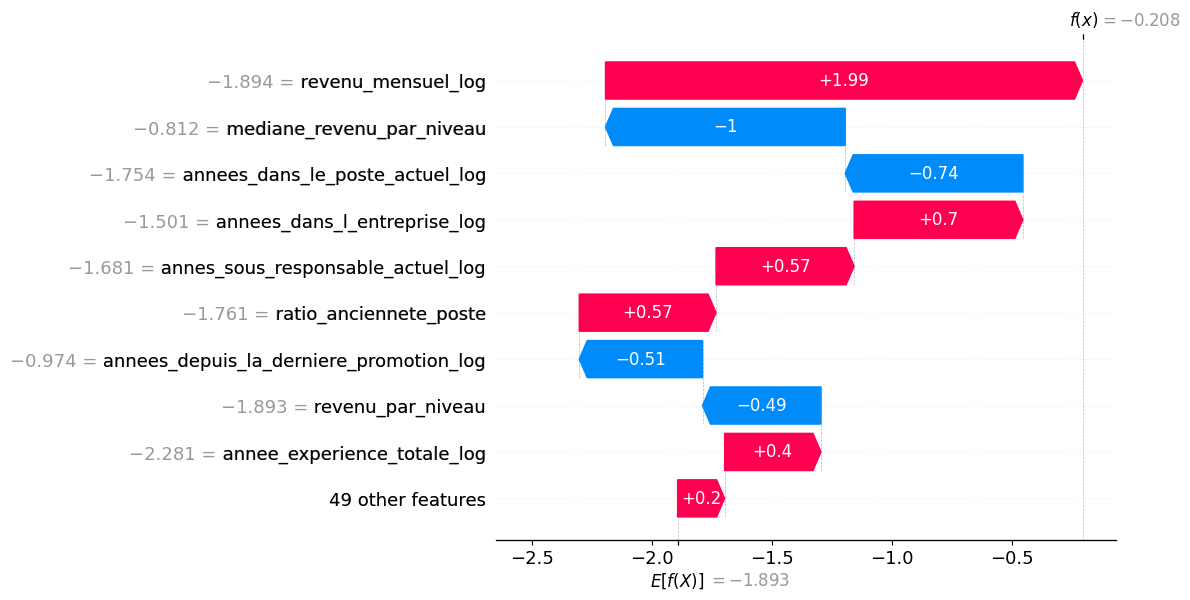


Observation predite = 0 | index = 1208
Base value (log-odds) : -1.8933
Base value (proba)    : 0.1309
f(x) final            : -3.0395
Proba pipeline        : 0.0118
Proba SHAP            : 0.0457
Seuil 0.5             : classe 0


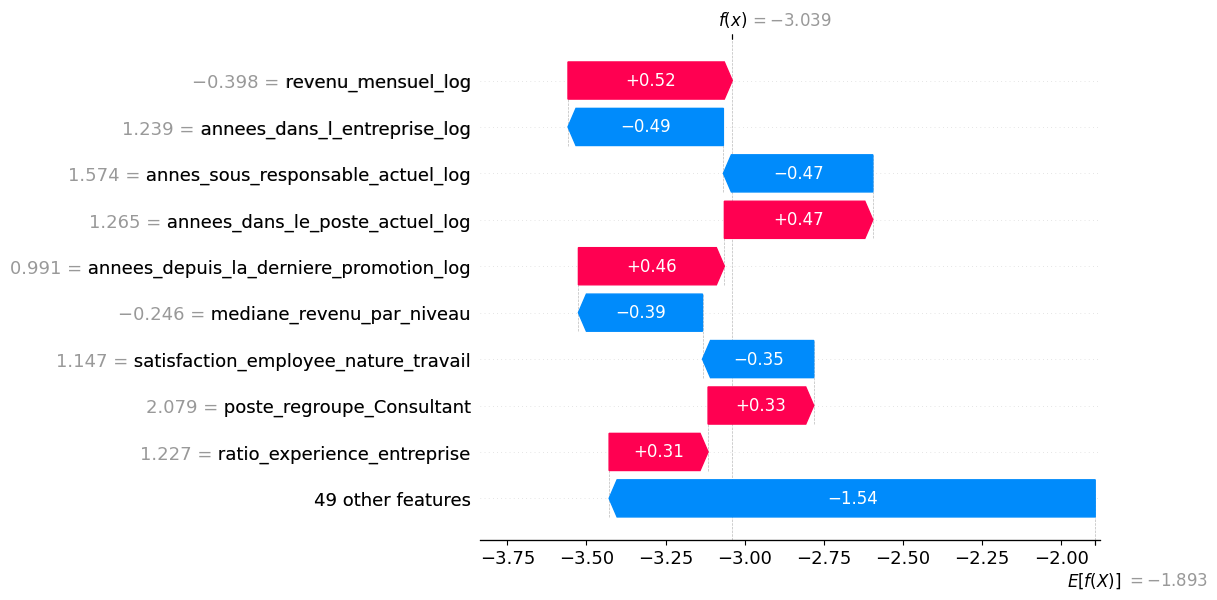

In [16]:
from scipy.special import expit

# 1) Colonnes exactement vues par le modèle
feature_names = logreg_best.feature_names_in_
X_logreg = X_model[feature_names]

# 2) Probabilités et classes prédites
proba_logreg_shap = logreg_best.predict_proba(X_logreg)[:, 1]
y_pred_logreg_shap = (proba_logreg_shap >= 0.5).astype(int)

# 3) Quelques exemples de chaque classe prédite
idx_pred_1 = X_logreg.index[y_pred_logreg_shap == 1][:3]
idx_pred_0 = X_logreg.index[y_pred_logreg_shap == 0][:3]

print("Nb pred 1 disponibles :", int((y_pred_logreg_shap == 1).sum()))
print("Nb pred 0 disponibles :", int((y_pred_logreg_shap == 0).sum()))
print("Indices pred 1 :", list(idx_pred_1))
print("Indices pred 0 :", list(idx_pred_0))

# 4) Objets SHAP
sv = shap_values.values if hasattr(shap_values, "values") else shap_values
base_value = (
    shap_values.base_values[0]
    if np.ndim(shap_values.base_values) > 0
    else shap_values.base_values
)

# 5) Fonction d'affichage
def plot_logreg_waterfall(idx, pred_label):
    i = X_logreg.index.get_loc(idx)

    fx_logit = base_value + sv[i].sum()
    fx_proba = expit(fx_logit)
    base_proba = expit(base_value)

    print(
        f"\nObservation predite = {pred_label} | index = {idx}\n"
        f"Base value (log-odds) : {base_value:.4f}\n"
        f"Base value (proba)    : {base_proba:.4f}\n"
        f"f(x) final            : {fx_logit:.4f}\n"
        f"Proba pipeline        : {proba_logreg_shap[i]:.4f}\n"
        f"Proba SHAP            : {fx_proba:.4f}\n"
        f"Seuil 0.5             : {'classe 1' if fx_proba >= 0.5 else 'classe 0'}"
    )

    shap.plots.waterfall(
        shap.Explanation(
            values=sv[i],
            base_values=base_value,
            data=X_model_scaled.iloc[i],
            feature_names=X_model_scaled.columns,
        ),
        max_display=10,
    )
    plt.show()
    plt.close()

# 6) Graphes classe 1
for idx in idx_pred_1:
    plot_logreg_waterfall(idx, pred_label=1)

# 7) Graphes classe 0
for idx in idx_pred_0:
    plot_logreg_waterfall(idx, pred_label=0)

Indices pred 1 : [414, 1153, 122]
Indices pred 0 : [141, 149, 1208]

Observation predite = 1 | index = 414


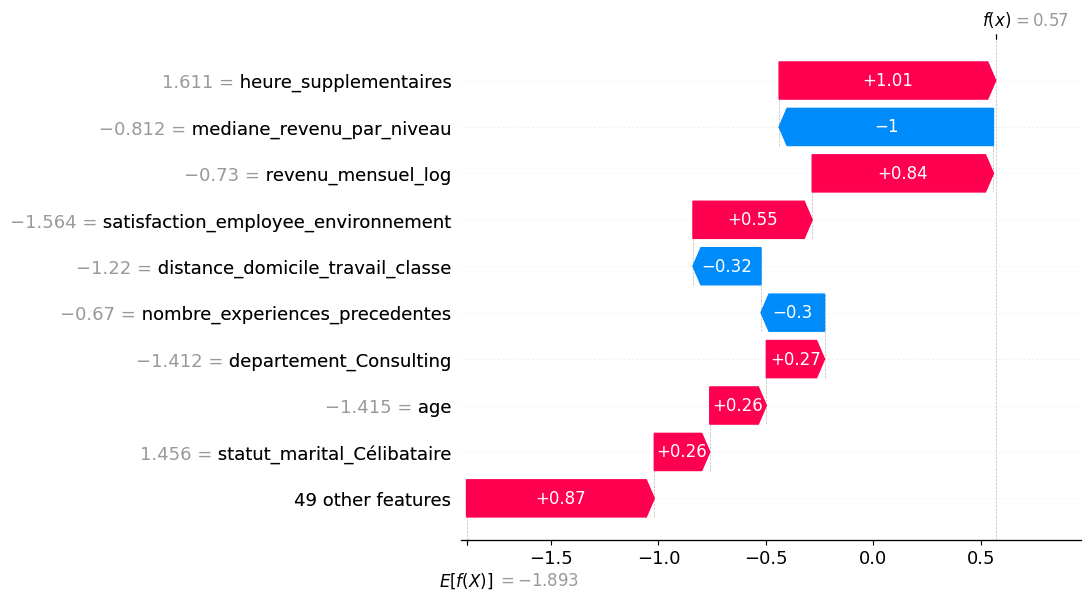


Observation predite = 1 | index = 1153


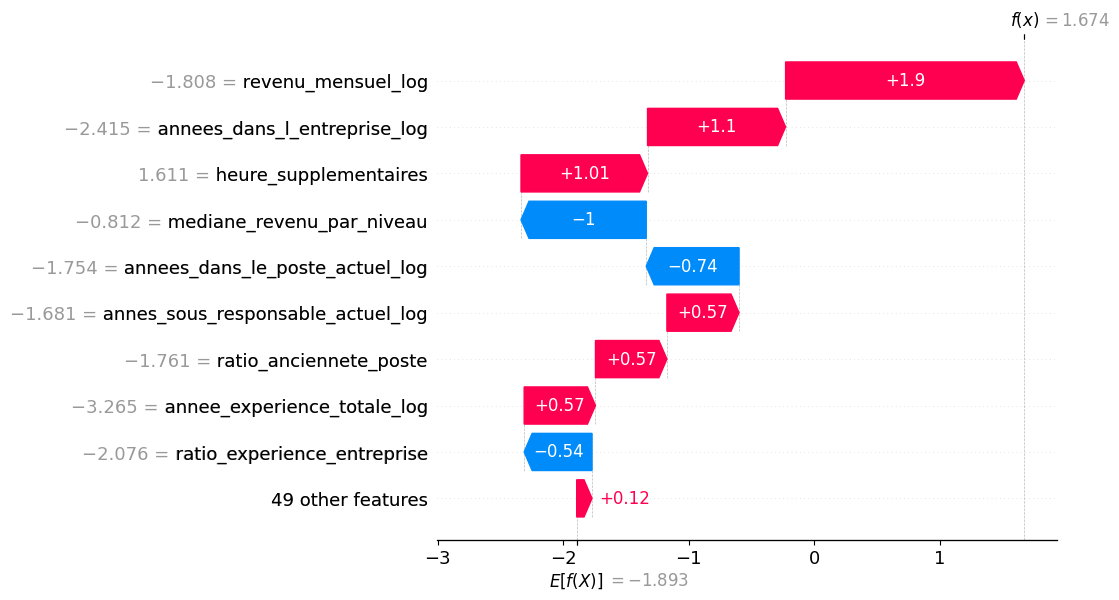


Observation predite = 1 | index = 122


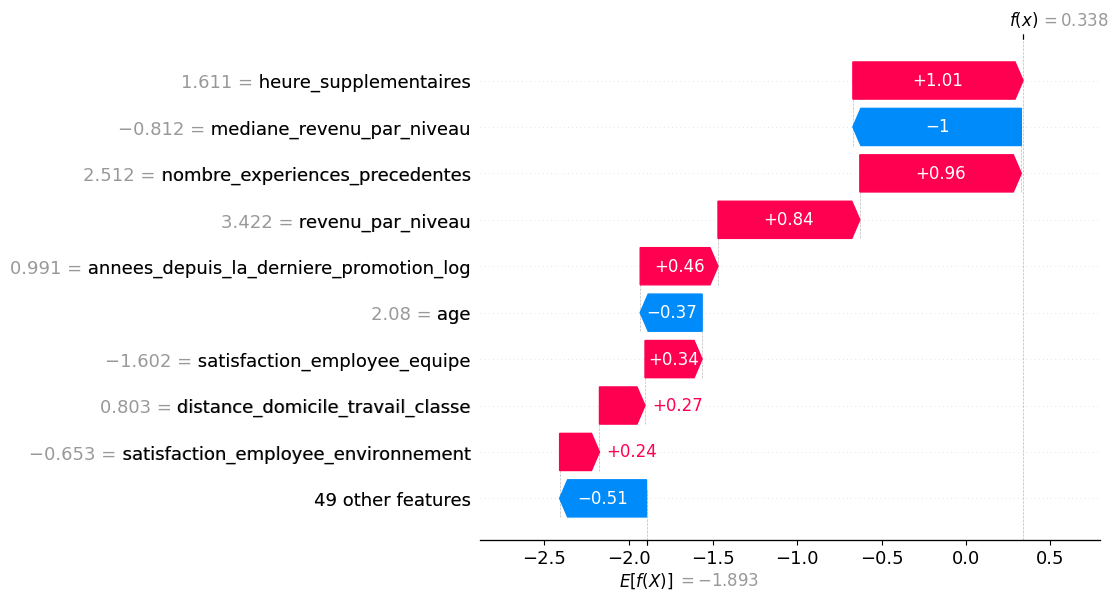


Observation predite = 0 | index = 141


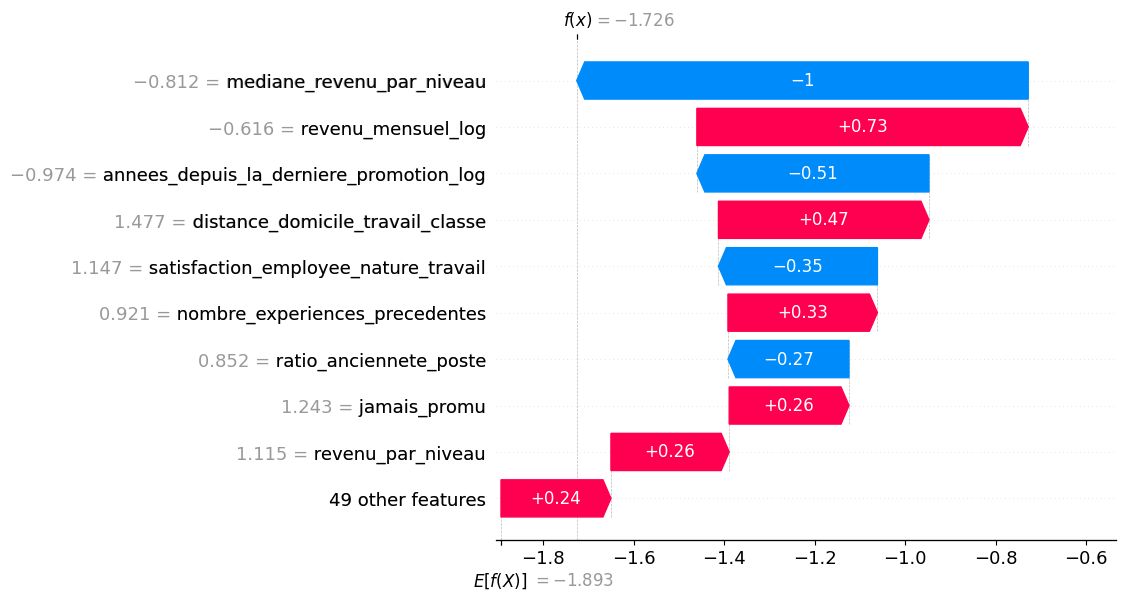


Observation predite = 0 | index = 149


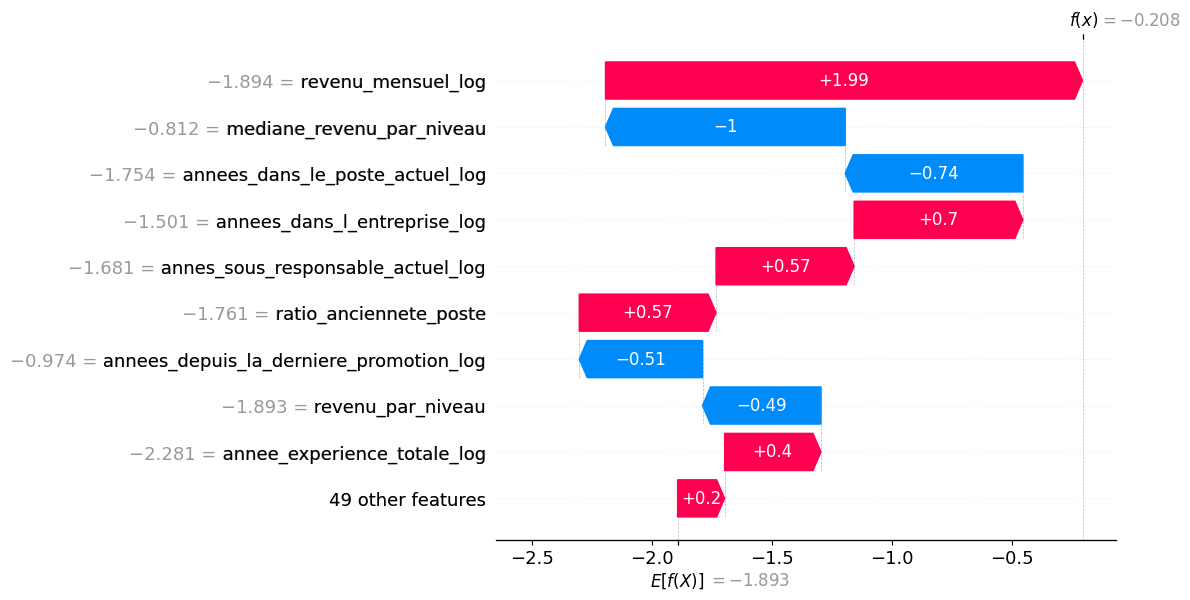


Observation predite = 0 | index = 1208


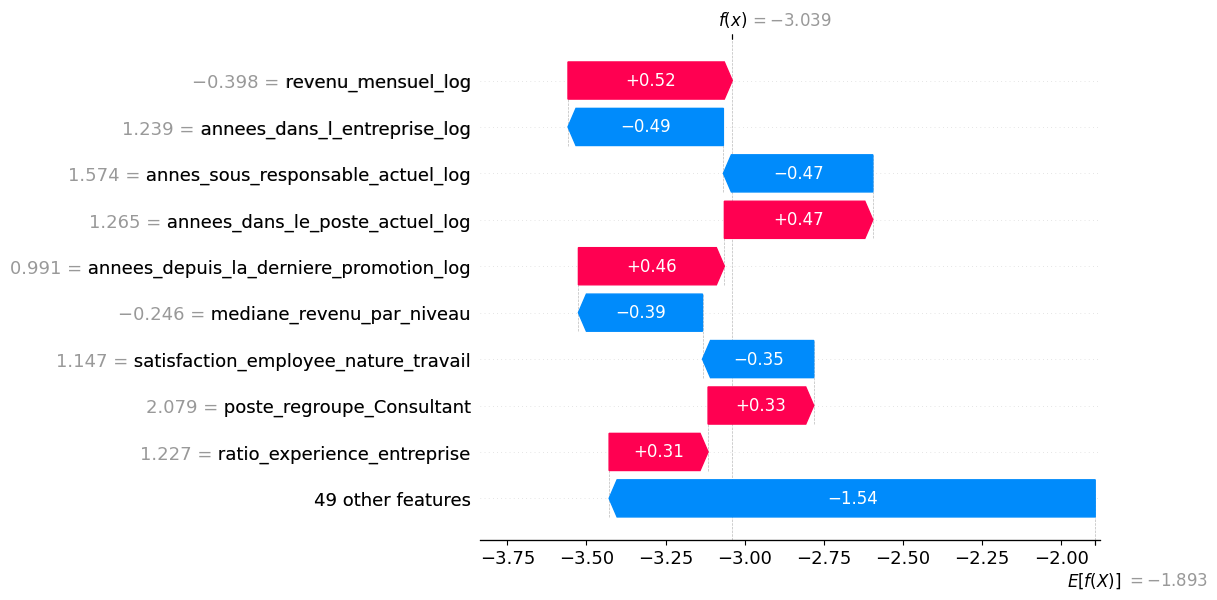

In [17]:
# 1) Dataset utilise pour SHAP
X_shap_svc = X_model[svc_best.feature_names_in_]

# 2) Predictions sur ce meme dataset
y_pred_svc_shap = svc_best.predict(X_shap_svc)

idx_pred_1 = X_shap_svc.index[y_pred_svc_shap == 1][:3]
idx_pred_0 = X_shap_svc.index[y_pred_svc_shap == 0][:3]

print("Indices pred 1 :", list(idx_pred_1))
print("Indices pred 0 :", list(idx_pred_0))

# 3) Base value + SHAP values
sv = shap_values.values if hasattr(shap_values, "values") else shap_values
base_value = (
    shap_values.base_values[0]
    if np.ndim(shap_values.base_values) > 0
    else shap_values.base_values
)

# 4) Waterfalls
for idx in idx_pred_1:
    i = X_shap_svc.index.get_loc(idx)
    print(f"\nObservation predite = 1 | index = {idx}")
    shap.plots.waterfall(
        shap.Explanation(
            values=sv[i],
            base_values=base_value,
            data=X_model_scaled.iloc[i],
            feature_names=X_model_scaled.columns,
        ),
        max_display=10,
    )
    plt.savefig(f"waterfall_svc_pred1_{idx}.png", dpi=150, bbox_inches="tight")
    plt.close()

for idx in idx_pred_0:
    i = X_shap_svc.index.get_loc(idx)
    print(f"\nObservation predite = 0 | index = {idx}")
    shap.plots.waterfall(
        shap.Explanation(
            values=sv[i],
            base_values=base_value,
            data=X_model_scaled.iloc[i],
            feature_names=X_model_scaled.columns,
        ),
        max_display=10,
    )
    plt.savefig(f"waterfall_svc_pred0_{idx}.png", dpi=150, bbox_inches="tight")
    plt.close()


**Les explications locales montrent que le modèle combine plusieurs signaux de faible à moyenne intensité pour produire la prédiction finale.**

Sur les exemples inspectés, on retrouve principalement :
- des contributions positives liées aux heures supplémentaires, à certains profils d’expérience et à des composantes de revenu ;
- des contributions négatives associées à l’absence d’heures supplémentaires, à certaines variables de satisfaction et à des marqueurs d’ancienneté/mobilité.

La décision finale provient surtout de la combinaison des effets, plus que d’une variable unique.

Maintenant que nous avons regardé des exemples aléatoires, nous examinons quelques faux positifs et faux négatifs.


Les FP/FN observés se situent majoritairement dans une zone de décision ambiguë proche du seuil.  

Le modèle arbitre entre signaux opposés (heures supplémentaires, satisfaction, expérience, revenu, participation au PEE, ancienneté).  

Aucun facteur unique ne domine systématiquement ; ce sont surtout des contributions combinées qui font basculer la prédiction.


## Second round de feature engineering
L’analyse des erreurs suggère que certaines situations restent insuffisamment captées par les variables actuelles, en particulier les cas où plusieurs signaux se compensent ou les départs plus discrets.  

Il apparaît donc pertinent d’enrichir le jeu de données avec de nouvelles variables dérivées visant à mieux retranscrire :  
- les effets de stagnation de carrière ;
- la sous-rémunération relative ; 
- l’incohérence entre performance et reconnaissance ; 
- ainsi que certaines interactions entre charge de travail, ancienneté et position hiérarchique.


In [18]:
df_MODEL.columns

Index(['id_employee', 'age', 'genre', 'nombre_experiences_precedentes',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'distance_domicile_travail',
       'niveau_education', 'revenu_mensuel_log', 'annee_experience_totale_log',
       'annees_dans_l_entreprise_log', 'annees_dans_le_poste_actuel_log',
       'annees_depuis_la_derniere_promotion_log',
       'annes_sous_responsable_actuel_log', 'distance_domicile_travail_classe',
       'ratio_anciennete_poste', 'ratio_anciennete_manager',
       'ratio_experience_entreprise', 'mobilite_interne_potentielle',
       'jamais_promu', 'retard_promotion_relatif',
  

In [19]:
# Copies de travail
X_model_fe = X_model.copy()
X_final_test_fe = X_final_test.copy()

On décide de tester les deux modèles présélectionnés au début du notebook, en remettant certaines valeurs à leur échelle normale :


In [20]:
# Seuils calcules uniquement sur X_model
note_eval_median = X_model["note_evaluation_actuelle"].median()
age_median = X_model["age"].median()
anciennete_median = X_model["annees_dans_l_entreprise_log"].median()

# 1. Heures supplementaires sans reconnaissance salariale
X_model["surcharge_sans_reconnaissance"] = (X_model["heure_supplementaires"] * (1 - X_model["augementation_salaire_precedente"]))
X_final_test["surcharge_sans_reconnaissance"] = (X_final_test["heure_supplementaires"] * (1 - X_final_test["augementation_salaire_precedente"]))

# 2. Heures supplementaires sans PEE
X_model["surcharge_sans_PEE"] = (X_model["heure_supplementaires"] * (X_model["nombre_participation_pee"] == 0).astype(int))
X_final_test["surcharge_sans_PEE"] = (X_final_test["heure_supplementaires"] * (X_final_test["nombre_participation_pee"] == 0).astype(int))


# 3. Bonne performance sans reconnaissance globale
X_model["bonne_perf_sans_reconnaissance_globale"] = ((X_model["note_evaluation_actuelle"] >= note_eval_median).astype(int) * (1 - X_model["augementation_salaire_precedente"]) * (X_model["annees_depuis_la_derniere_promotion_log"] > 0).astype(int))
X_final_test["bonne_perf_sans_reconnaissance_globale"] = ((X_final_test["note_evaluation_actuelle"] >= note_eval_median).astype(int) * (1 - X_final_test["augementation_salaire_precedente"]) * (X_final_test["annees_depuis_la_derniere_promotion_log"] > 0).astype(int))

# 4. Stagnation manageriale
X_model["stagnation_manageriale"] = (X_model["annes_sous_responsable_actuel_log"] * (1 - X_model["mobilite_interne_potentielle"]))
X_final_test["stagnation_manageriale"] = (X_final_test["annes_sous_responsable_actuel_log"] * (1 - X_final_test["mobilite_interne_potentielle"]))

# 5. Sous-positionnement experience / niveau
X_model["sous_positionnement_experience"] = (X_model["annee_experience_totale_log"] / (X_model["niveau_hierarchique_poste"] + 1))
X_final_test["sous_positionnement_experience"] = (X_final_test["annee_experience_totale_log"] / (X_final_test["niveau_hierarchique_poste"] + 1))

# 6. Jeune salarie avec heures supplementaires
X_model["jeune_avec_heures_sup"] = ((X_model["age"] <= age_median).astype(int) * X_model["heure_supplementaires"])
X_final_test["jeune_avec_heures_sup"] = ((X_final_test["age"] <= age_median).astype(int) * X_final_test["heure_supplementaires"])

# 7. Anciennete courte
X_model["anciennete_courte"] = (X_model["annees_dans_l_entreprise_log"] <= anciennete_median).astype(int)
X_final_test["anciennete_courte"] = (X_final_test["annees_dans_l_entreprise_log"] <= anciennete_median).astype(int)

# 8. Anciennete sans progression
X_model["anciennete_sans_progression"] = (X_model["annees_dans_l_entreprise_log"] * X_model["retard_promotion_relatif"])
X_final_test["anciennete_sans_progression"] = (X_final_test["annees_dans_l_entreprise_log"] * X_final_test["retard_promotion_relatif"])

# 9. Enlisement dans le poste
X_model["enlisement_poste"] = (X_model["annees_dans_le_poste_actuel_log"] * X_model["ratio_anciennete_poste"])
X_final_test["enlisement_poste"] = (X_final_test["annees_dans_le_poste_actuel_log"] * X_final_test["ratio_anciennete_poste"])

# 10. Anciennete sous le meme manager
X_model["anciennete_sous_meme_manager"] = (X_model["annees_dans_l_entreprise_log"] * X_model["annes_sous_responsable_actuel_log"])
X_final_test["anciennete_sous_meme_manager"] = (X_final_test["annees_dans_l_entreprise_log"] * X_final_test["annes_sous_responsable_actuel_log"])


In [21]:
num_cols = [
    "age",
    "revenu_mensuel_log",
    "nombre_experiences_precedentes",
    "annee_experience_totale_log",
    "annees_dans_l_entreprise_log",
    "annees_dans_le_poste_actuel_log",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "annees_depuis_la_derniere_promotion_log",
    "annes_sous_responsable_actuel_log",
    "augementation_salaire_precedente",
]

nouvelles_cols = [
    "surcharge_sans_reconnaissance",
    "surcharge_sans_PEE",
    "bonne_perf_sans_reconnaissance_globale",
    "stagnation_manageriale",
    "sous_positionnement_experience",
    "jeune_avec_heures_sup",
    "anciennete_courte",
    "anciennete_sans_progression",
    "enlisement_poste",
    "anciennete_sous_meme_manager",
]


In [76]:
# Sous-ensemble pour l'analyse
corr_candidates = num_cols + nouvelles_cols

# Matrice de corrélation de Pearson
corr_matrix = X_model[corr_candidates].corr(method="pearson")

# Extraction des paires uniques
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().reset_index())
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

# Filtre : corrélation absolue > 0.6
strong_corr = (corr_pairs[corr_pairs["abs_correlation"] > 0.6].sort_values("abs_correlation", ascending=False).reset_index(drop=True))
strong_corr[["feature_1", "feature_2", "correlation"]]

,feature_1,feature_2,correlation
0,annees_depuis_la_derniere_promotion_log,anciennete_sans_progression,0.955782
1,annes_sous_responsable_actuel_log,anciennete_sous_meme_manager,0.941299
2,revenu_mensuel_log,niveau_hierarchique_poste,0.921407
3,annees_dans_le_poste_actuel_log,enlisement_poste,0.896949
4,annees_dans_l_entreprise_log,anciennete_sous_meme_manager,0.886697
5,annees_dans_l_entreprise_log,annees_dans_le_poste_actuel_log,0.834396
6,annees_dans_l_entreprise_log,annes_sous_responsable_actuel_log,0.823011
7,annees_dans_l_entreprise_log,anciennete_courte,-0.796666
8,annees_depuis_la_derniere_promotion_log,bonne_perf_sans_reconnaissance_globale,0.780523
9,note_evaluation_actuelle,augementation_salaire_precedente,0.770017


In [22]:
# Variables à supprimer (forte redondance / risque d'overfit)
cols_to_drop = [
    "anciennete_sous_meme_manager",
    "enlisement_poste",
    "anciennete_sans_progression"
]

# Suppression dans train et test
X_model = X_model.drop(columns=cols_to_drop, errors="ignore")
X_final_test = X_final_test.drop(columns=cols_to_drop, errors="ignore")

print("Colonnes supprimées :", cols_to_drop)
print("Nouvelle shape X_model :", X_model.shape)
print("Nouvelle shape X_final_test :", X_final_test.shape)


Colonnes supprimées : ['anciennete_sous_meme_manager', 'enlisement_poste', 'anciennete_sans_progression']
Nouvelle shape X_model : (1176, 65)
Nouvelle shape X_final_test : (294, 65)


In [23]:
X_model.columns

Index(['age', 'genre', 'nombre_experiences_precedentes',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'nombre_participation_pee', 'nb_formations_suivies',
       'distance_domicile_travail', 'niveau_education', 'revenu_mensuel_log',
       'annee_experience_totale_log', 'annees_dans_l_entreprise_log',
       'annees_dans_le_poste_actuel_log',
       'annees_depuis_la_derniere_promotion_log',
       'annes_sous_responsable_actuel_log', 'distance_domicile_travail_classe',
       'ratio_anciennete_poste', 'ratio_anciennete_manager',
       'ratio_experience_entreprise', 'mobilite_interne_potentielle',
       'jamais_promu', 'retard_promotion_relatif',
       'progression_salariale_faible', 'me


Logistic Regression
Train | Accuracy: 0.9073 +/- 0.0052 | Precision: 0.8390 +/- 0.0142 | Recall: 0.5276 +/- 0.0366 | F1: 0.6471 +/- 0.0287 | ROC AUC: 0.8817 +/- 0.0072 | PR-AUC: 0.7360 +/- 0.0232
Test  | Accuracy: 0.8861 +/- 0.0221 | Precision: 0.7288 +/- 0.1037 | Recall: 0.4737 +/- 0.0865 | F1: 0.5714 +/- 0.0868 | ROC AUC: 0.8258 +/- 0.0409 | PR-AUC: 0.6287 +/- 0.0730
Temps | Total CV: 0.4601s | Moyenne par fold: 0.0456s +/- 0.0063s


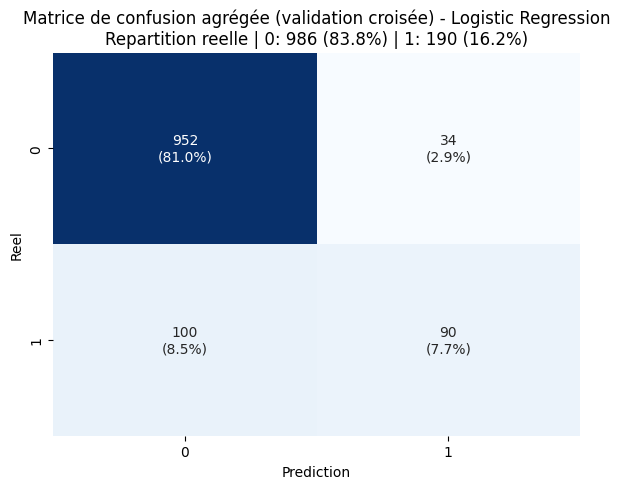


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93       986
         1.0       0.73      0.47      0.57       190

    accuracy                           0.89      1176
   macro avg       0.82      0.72      0.75      1176
weighted avg       0.88      0.89      0.88      1176


Linear SVC
Train | Accuracy: 0.9073 +/- 0.0061 | Precision: 0.8567 +/- 0.0176 | Recall: 0.5118 +/- 0.0385 | F1: 0.6401 +/- 0.0320 | ROC AUC: 0.8819 +/- 0.0075 | PR-AUC: 0.7325 +/- 0.0222
Test  | Accuracy: 0.8861 +/- 0.0189 | Precision: 0.7550 +/- 0.1099 | Recall: 0.4474 +/- 0.0686 | F1: 0.5583 +/- 0.0733 | ROC AUC: 0.8236 +/- 0.0397 | PR-AUC: 0.6227 +/- 0.0706
Temps | Total CV: 0.4115s | Moyenne par fold: 0.0401s +/- 0.0071s


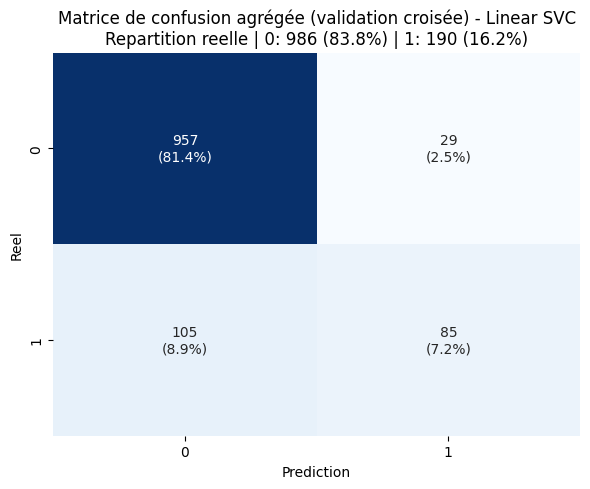


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93       986
         1.0       0.75      0.45      0.56       190

    accuracy                           0.89      1176
   macro avg       0.82      0.71      0.75      1176
weighted avg       0.88      0.89      0.87      1176


SVC
Train | Accuracy: 0.9252 +/- 0.0088 | Precision: 0.9932 +/- 0.0056 | Recall: 0.5408 +/- 0.0571 | F1: 0.6984 +/- 0.0470 | ROC AUC: 0.9749 +/- 0.0034 | PR-AUC: 0.9475 +/- 0.0052
Test  | Accuracy: 0.8682 +/- 0.0139 | Precision: 0.8210 +/- 0.1128 | Recall: 0.2316 +/- 0.0586 | F1: 0.3602 +/- 0.0804 | ROC AUC: 0.8147 +/- 0.0465 | PR-AUC: 0.6076 +/- 0.0854
Temps | Total CV: 2.1715s | Moyenne par fold: 0.3075s +/- 0.0282s


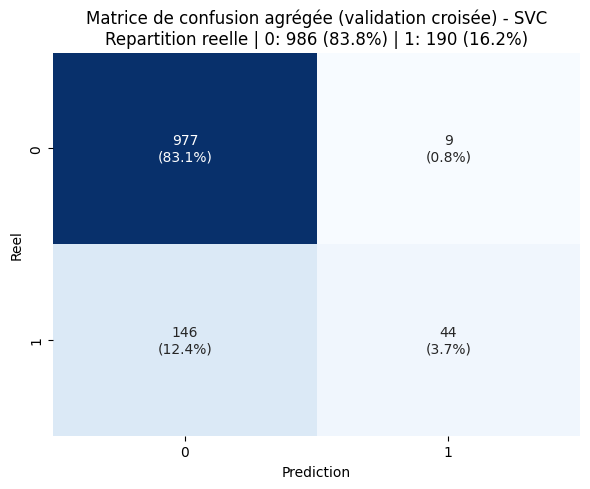


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93       986
         1.0       0.83      0.23      0.36       190

    accuracy                           0.87      1176
   macro avg       0.85      0.61      0.64      1176
weighted avg       0.86      0.87      0.84      1176


KNeighbors Classifier
Train | Accuracy: 0.8884 +/- 0.0055 | Precision: 0.9003 +/- 0.0209 | Recall: 0.3487 +/- 0.0430 | F1: 0.5008 +/- 0.0430 | ROC AUC: 0.9203 +/- 0.0086 | PR-AUC: 0.6538 +/- 0.0264
Test  | Accuracy: 0.8520 +/- 0.0076 | Precision: 0.6390 +/- 0.0890 | Recall: 0.2000 +/- 0.0357 | F1: 0.3029 +/- 0.0448 | ROC AUC: 0.7130 +/- 0.0481 | PR-AUC: 0.3918 +/- 0.0594
Temps | Total CV: 0.6294s | Moyenne par fold: 0.0445s +/- 0.0144s


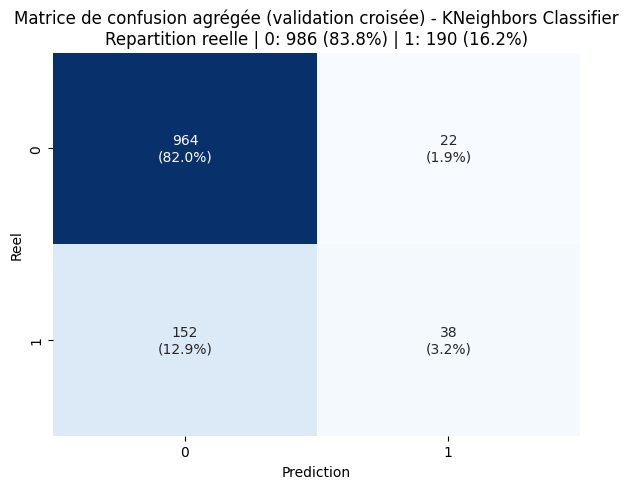


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       986
         1.0       0.63      0.20      0.30       190

    accuracy                           0.85      1176
   macro avg       0.75      0.59      0.61      1176
weighted avg       0.83      0.85      0.82      1176


Decision Tree
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.7704 +/- 0.0195 | Precision: 0.3073 +/- 0.0527 | Recall: 0.3368 +/- 0.0653 | F1: 0.3208 +/- 0.0575 | ROC AUC: 0.5954 +/- 0.0354 | PR-AUC: 0.2138 +/- 0.0280
Temps | Total CV: 0.4863s | Moyenne par fold: 0.0391s +/- 0.0052s


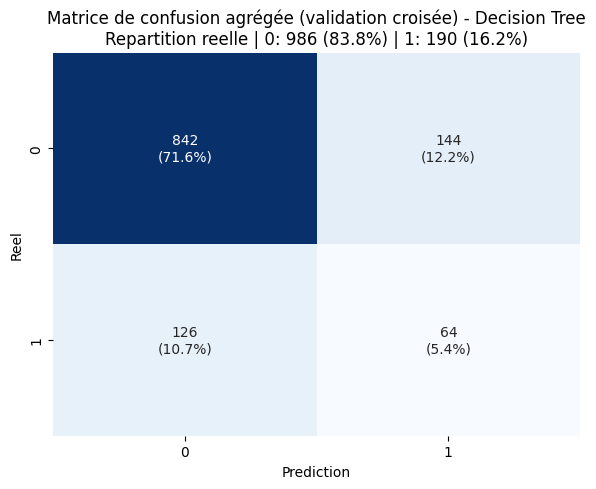


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       986
         1.0       0.31      0.34      0.32       190

    accuracy                           0.77      1176
   macro avg       0.59      0.60      0.59      1176
weighted avg       0.78      0.77      0.77      1176


Random Forest
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8639 +/- 0.0114 | Precision: 0.7943 +/- 0.1263 | Recall: 0.2105 +/- 0.0440 | F1: 0.3324 +/- 0.0653 | ROC AUC: 0.7819 +/- 0.0342 | PR-AUC: 0.5338 +/- 0.0360
Temps | Total CV: 2.3556s | Moyenne par fold: 0.3885s +/- 0.0474s


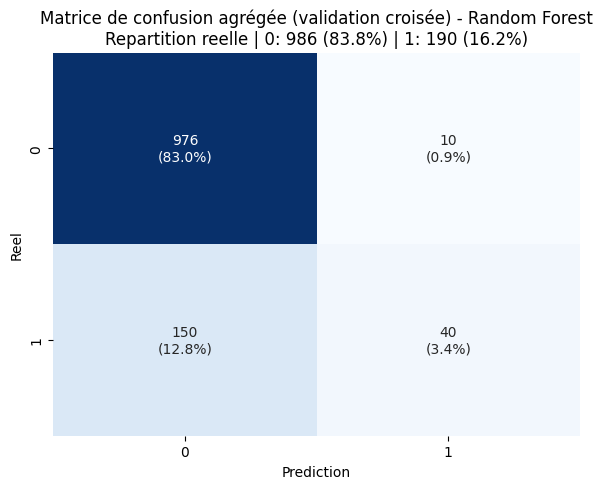


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92       986
         1.0       0.80      0.21      0.33       190

    accuracy                           0.86      1176
   macro avg       0.83      0.60      0.63      1176
weighted avg       0.86      0.86      0.83      1176


Extra Trees
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000 | PR-AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8639 +/- 0.0112 | Precision: 0.7751 +/- 0.1094 | Recall: 0.2211 +/- 0.0459 | F1: 0.3430 +/- 0.0646 | ROC AUC: 0.7849 +/- 0.0593 | PR-AUC: 0.5351 +/- 0.0806
Temps | Total CV: 2.3431s | Moyenne par fold: 0.3736s +/- 0.1169s


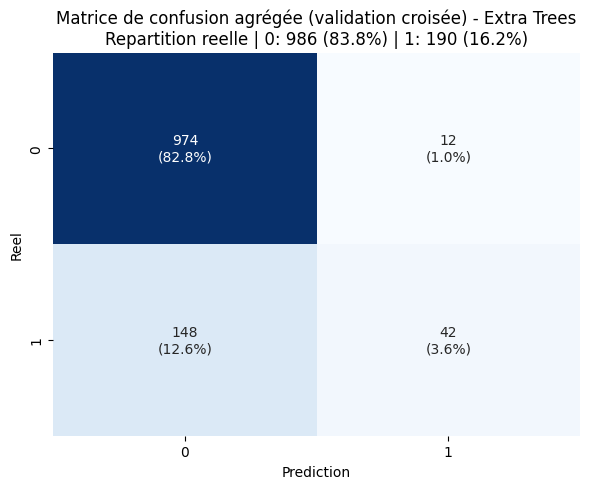


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92       986
         1.0       0.78      0.22      0.34       190

    accuracy                           0.86      1176
   macro avg       0.82      0.60      0.63      1176
weighted avg       0.85      0.86      0.83      1176


Gradient Boosting
Train | Accuracy: 0.9664 +/- 0.0026 | Precision: 0.9983 +/- 0.0033 | Recall: 0.7934 +/- 0.0148 | F1: 0.8841 +/- 0.0096 | ROC AUC: 0.9951 +/- 0.0024 | PR-AUC: 0.9833 +/- 0.0068
Test  | Accuracy: 0.8673 +/- 0.0177 | Precision: 0.6915 +/- 0.0850 | Recall: 0.3211 +/- 0.1031 | F1: 0.4320 +/- 0.0986 | ROC AUC: 0.7741 +/- 0.0405 | PR-AUC: 0.5198 +/- 0.0933
Temps | Total CV: 3.3155s | Moyenne par fold: 0.6233s +/- 0.0115s


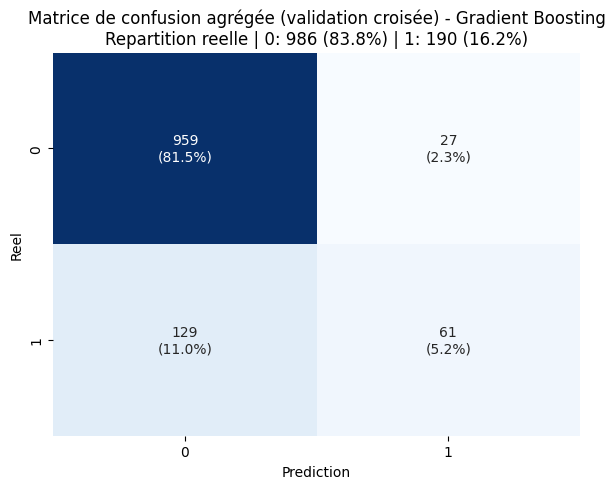


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92       986
         1.0       0.69      0.32      0.44       190

    accuracy                           0.87      1176
   macro avg       0.79      0.65      0.68      1176
weighted avg       0.85      0.87      0.85      1176


AdaBoost
Train | Accuracy: 0.8863 +/- 0.0035 | Precision: 0.8761 +/- 0.0477 | Recall: 0.3487 +/- 0.0422 | F1: 0.4960 +/- 0.0366 | ROC AUC: 0.8974 +/- 0.0123 | PR-AUC: 0.7113 +/- 0.0206
Test  | Accuracy: 0.8614 +/- 0.0100 | Precision: 0.7049 +/- 0.0935 | Recall: 0.2474 +/- 0.0268 | F1: 0.3660 +/- 0.0411 | ROC AUC: 0.7998 +/- 0.0447 | PR-AUC: 0.5474 +/- 0.0611
Temps | Total CV: 1.5015s | Moyenne par fold: 0.2422s +/- 0.0287s


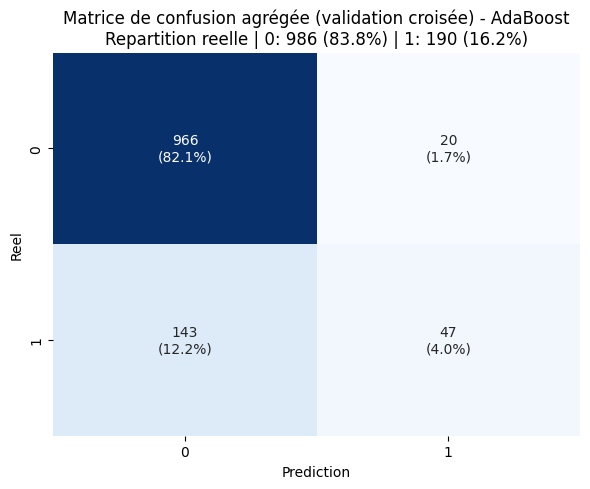


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92       986
         1.0       0.70      0.25      0.37       190

    accuracy                           0.86      1176
   macro avg       0.79      0.61      0.64      1176
weighted avg       0.84      0.86      0.83      1176



In [24]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),

    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, dual="auto", max_iter=5000)),
    ]),

    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42)),
    ]),

    "KNeighbors Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42,
    ),
}


for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(model=model,X=X_model,y=y_model,cv=5,stratify=True,model_name=name,)

In [25]:
models = {
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=10000, random_state=42))]),
        {
            "model__C": [0.001, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
            "model__class_weight": [None, "balanced", {0: 1, 1: 1.2}, {0: 1, 1: 1.5}, {0: 1, 1: 2}, {0: 1, 1: 3}],
            "model__solver": ["lbfgs", "liblinear"],
        },
    ),
    "Linear SVC": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearSVC(max_iter=100000, random_state=42, dual="auto"))]),
        {
            "model__C": [0.001, 0.01, 0.03, 0.1, 0.3, 1, 3, 10],
            "model__loss": ["squared_hinge"],
            "model__class_weight": [None, "balanced", {0: 1, 1: 1.2}, {0: 1, 1: 1.5}, {0: 1, 1: 2}, {0: 1, 1: 3}],
        },
    ),
}

score_fn = lambda m, X: m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(X)

results_f1 = {
    name: Fonctions_MODEL.optimize_classification_hyperparameters(
        model=model, param_grid=grid, X=X_model, y=y_model, cv=5, scoring="f1",
        stratify=True, search_type="grid", n_iter=20, model_name=name
    )
    for name, (model, grid) in models.items()
}



Logistic Regression
GridSearchCV | Scoring : f1 | Meilleur score CV : 0.5938
Meilleurs hyperparametres : {'model__C': 0.01, 'model__class_weight': {0: 1, 1: 2}, 'model__solver': 'liblinear'}

Linear SVC
GridSearchCV | Scoring : f1 | Meilleur score CV : 0.5912
Meilleurs hyperparametres : {'model__C': 0.03, 'model__class_weight': {0: 1, 1: 2}, 'model__loss': 'squared_hinge'}


In [26]:
Xtr, Xva, ytr, yva = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

threshold_results = {}
for name, res in results_f1.items():
    model = res["Best Estimator"].fit(Xtr, ytr)
    scores = score_fn(model, Xva)
    ts = np.linspace(scores.min(), scores.max(), 400)
    f1s = [f1_score(yva, (scores >= t).astype(int), zero_division=0) for t in ts]
    t = ts[np.argmax(f1s)]
    yp = (scores >= t).astype(int)
    threshold_results[name] = {
        "Seuil": float(t),
        "Precision": precision_score(yva, yp, zero_division=0),
        "Recall": recall_score(yva, yp, zero_division=0),
        "F1": f1_score(yva, yp, zero_division=0),
    }
    print(f"{name} -> seuil={t:.4f} | Precision={threshold_results[name]['Precision']:.4f} | Recall={threshold_results[name]['Recall']:.4f} | F1={threshold_results[name]['F1']:.4f}")

best_name = max(threshold_results, key=lambda n: threshold_results[n]["F1"])
t = threshold_results[best_name]["Seuil"]

Logistic Regression -> seuil=0.4780 | Precision=0.4828 | Recall=0.7368 | F1=0.5833
Linear SVC -> seuil=0.1138 | Precision=0.6053 | Recall=0.6053 | F1=0.6053


#### Après optimisation orientée F1 puis réglage du seuil, le Linear SVC obtient le meilleur compromis sur la validation interne.

#### Logistic Regression : seuil = 0.4780, Precision = 0.4828, Recall = 0.7368, F1 = 0.5833.

#### Linear SVC : seuil = 0.1138, Precision = 0.6053, Recall = 0.6053, F1 = 0.6053.

#### Le Linear SVC est retenu pour le test final (meilleur F1 et meilleure précision sur cette phase).


,Variable,Importance Moyenne,Ecart-Type
17,annee_experience_totale_log,0.135378,0.016669
30,mediane_revenu_par_niveau,0.065198,0.011698
16,revenu_mensuel_log,0.059969,0.015918
2,nombre_experiences_precedentes,0.054908,0.019663
49,poste_regroupe_Consultant,0.037691,0.012052
3,satisfaction_employee_environnement,0.036926,0.014007
63,jeune_avec_heures_sup,0.022456,0.014133
6,satisfaction_employee_nature_travail,0.019647,0.009633
13,nb_formations_suivies,0.018160,0.007946
18,annees_dans_l_entreprise_log,0.018112,0.009484


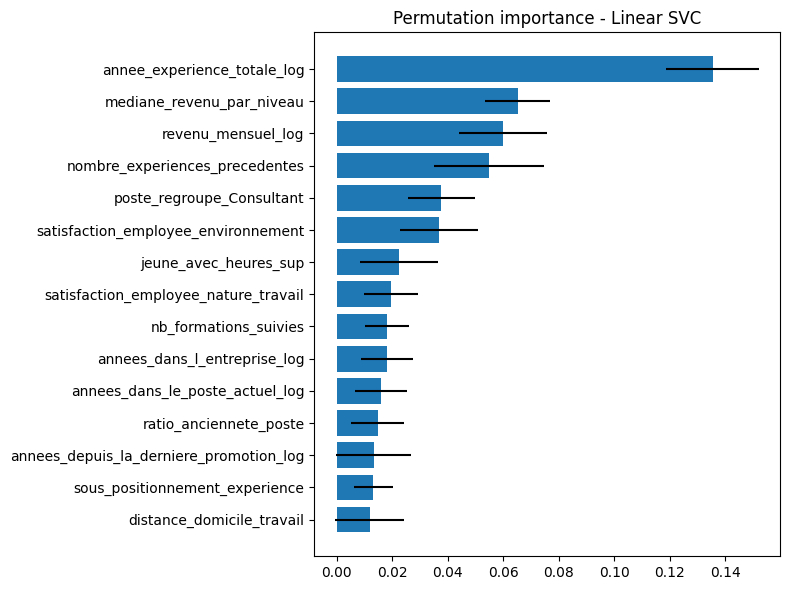

In [29]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

model = results_f1[best_name]["Best Estimator"].fit(X_model, y_model)
model.fit(X_model, y_model)

perm = permutation_importance(
    model,
    X_model,
    y_model,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_model.columns,
    "Importance Moyenne": perm.importances_mean,
    "Ecart-Type": perm.importances_std,
}).sort_values("Importance Moyenne", ascending=False)

display(importance_df.head(15))

top = importance_df.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["Variable"], top["Importance Moyenne"], xerr=top["Ecart-Type"])
plt.title("Permutation importance - Linear SVC")
plt.tight_layout()
plt.show()

## Test de performance final

On passe au test final sur le dataset mis de côté au départ.

Dans la cellule ci-dessous, l’évaluation finale est exécutée avec le meilleur modèle retenu après optimisation et réglage du seuil, ici le Linear SVC.



Linear SVC - Test final
Train | Accuracy: 0.8980 | Precision: 0.7431 | Recall: 0.5632 | F1: 0.6407 | ROC AUC: 0.8746 | PR-AUC: 0.7134
Test  | Accuracy: 0.8946 | Precision: 0.7353 | Recall: 0.5319 | F1: 0.6173 | ROC AUC: 0.8769 | PR-AUC: 0.6856

Classification report (test final):
              precision    recall  f1-score   support

           0     0.9154    0.9636    0.9389       247
           1     0.7353    0.5319    0.6173        47

    accuracy                         0.8946       294
   macro avg     0.8253    0.7477    0.7781       294
weighted avg     0.8866    0.8946    0.8874       294



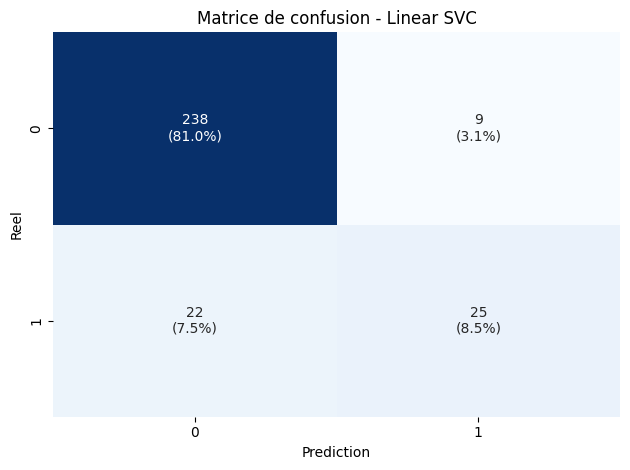

In [34]:
from sklearn.metrics import average_precision_score

final_model = results_f1[best_name]["Best Estimator"].fit(X_model, y_model)

proba_train, proba_test = score_fn(final_model, X_model), score_fn(final_model, X_final_test)
pred_train, pred_test = (proba_train >= t).astype(int), (proba_test >= t).astype(int)

print(f"\n{best_name} - Test final")
print(
    f"Train | Accuracy: {accuracy_score(y_model, pred_train):.4f} | "
    f"Precision: {precision_score(y_model, pred_train, zero_division=0):.4f} | "
    f"Recall: {recall_score(y_model, pred_train, zero_division=0):.4f} | "
    f"F1: {f1_score(y_model, pred_train, zero_division=0):.4f} | "
    f"ROC AUC: {roc_auc_score(y_model, proba_train):.4f} | "
    f"PR-AUC: {average_precision_score(y_model, proba_train):.4f}"
)
print(
    f"Test  | Accuracy: {accuracy_score(y_final_test, pred_test):.4f} | "
    f"Precision: {precision_score(y_final_test, pred_test, zero_division=0):.4f} | "
    f"Recall: {recall_score(y_final_test, pred_test, zero_division=0):.4f} | "
    f"F1: {f1_score(y_final_test, pred_test, zero_division=0):.4f} | "
    f"ROC AUC: {roc_auc_score(y_final_test, proba_test):.4f} | "
    f"PR-AUC: {average_precision_score(y_final_test, proba_test):.4f}"
)

print("\nClassification report (test final):")
print(classification_report(y_final_test, pred_test, digits=4, zero_division=0))

cm = confusion_matrix(y_final_test, pred_test)
cm_pct = cm / cm.sum() * 100

labels = np.array([
    [f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["0", "1"],
    yticklabels=["0", "1"],
)

plt.title(f"Matrice de confusion - {best_name}")
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.tight_layout()
plt.show()




## Récapitulatif final et interprétation

### 1) Résumé des choix méthodologiques
- Split final sanctuarisé : **80% modélisation / 20% test final**.
- Benchmark de plusieurs familles de modèles (linéaires, arbres, ensembles, SVM, voisins).
- Optimisation des hyperparamètres puis réglage de seuil sur validation interne.
- Évaluation finale réalisée **une seule fois** sur le test final.

### 2) Résultats clés
- Phase de réglage de seuil (LR/SVC/AdaBoost) : **LR** obtient le meilleur F1 (**0.5889**) avec un seuil de **0.3536**, devant **SVC** (**F1 = 0.5814**, seuil = **0.3654**).
- Phase finale (LR vs Linear SVC) :
  - LR : seuil=0.4780, Precision=0.4828, Recall=0.7368, F1=0.5833
  - Linear SVC : seuil=0.1138, Precision=0.6053, Recall=0.6053, F1=0.6053
- Test final (Linear SVC) : **Acc=0.8946, Precision=0.7353, Recall=0.5319, F1=0.6173, AUC=0.8769**.

### 3) Interprétation
- Le **Linear SVC** devient le meilleur modèle final sur cette itération, avec un gain net en précision et en F1 sur le test final.
- L’AUC finale (**0.8769**) confirme un bon pouvoir de discrimination sur le test final, proche de celui observé pour la régression logistique.
- Les analyses d’importance (coefficients, permutation, SHAP) convergent vers des facteurs robustes : rémunération, heures supplémentaires, ancienneté/progression et, plus secondairement, certaines dimensions de satisfaction ou de mobilité.
